In [1]:
import sys
sys.path.append("../python/")
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as colors
from matplotlib.offsetbox import AnchoredText
%matplotlib inline
from _corner import corner
import pickle
from scipy.stats import gaussian_kde, binned_statistic
from scipy.interpolate import UnivariateSpline, griddata
from scipy.optimize import minimize
import utils
import imp
imp.reload(utils)
from utils import temperature_withDM

from matplotlib import rc
rc('font', family='times new roman', size=18.)

Plot posterior and ML estimators

0.40842391788918375 1.0483570385720413 5.939668183834853


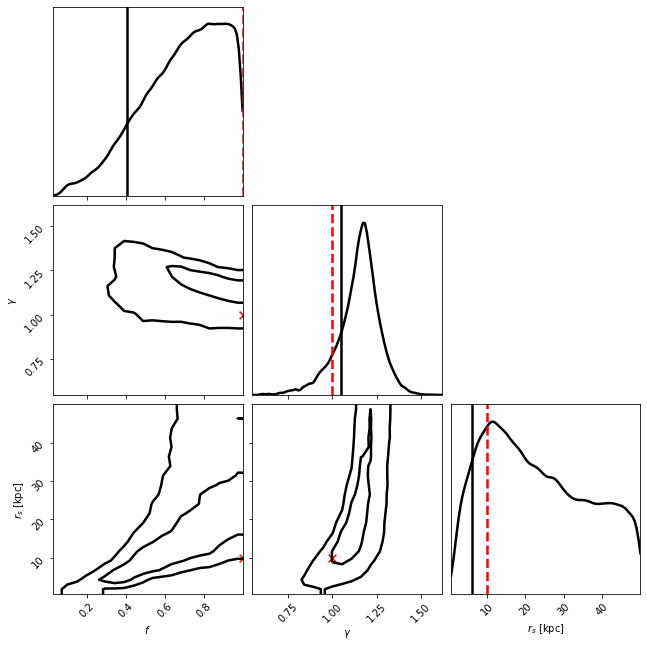

In [2]:
nBDs = 1000; relT = 0.10; relM = 0.10; ex = "ex25"
f_true=1.; rs_true = 10.; gamma_true=1.

_path   = "/hdfs/local/mariacst/exoplanets/results/final_round/"
_file   = open(_path + 
               "likelihood/all_unc/velocity/v200/N%irelT%.2frelM%.2f/like_" %(nBDs, relT, relM) +
               ex + 
               "_N%i_relunc%.2f_relM%.2f_f%.1fgamma%.1frs%.1fv50" %(nBDs, relT, relM, f_true, gamma_true, rs_true),
               "rb") 
like    = pickle.load(_file)
_file   = open(_path + 
               "all_unc/velocity/v200/N%irelT%.2frelM%.2f/posterior_" %(nBDs, relT, relM) +
               ex + 
               "_N%i_relunc%.2f_relM%.2f_f%.1fgamma%.1frs%.1fv50" %(nBDs, relT, relM, f_true, gamma_true, rs_true),
               "rb") 
samples = pickle.load(_file)

smooth=0.5
fig, axes = corner(samples, levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
                   plot_density=False, fill_contours=False, smooth=smooth)

# plot KDE smoothed version of distributions
for axidx, samps in zip([0, 4, 8], samples.T):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim()
    xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="k", lw=2.5) 

ML = samples[np.argmax(like)]
axes[0, 0].axvline(ML[0], ls="-", lw=2.5, color="k"); axes[0, 0].axvline(f_true, color="r", ls="--", lw=2.5)
axes[1, 1].axvline(ML[1], ls="-", lw=2.5, color="k"); axes[1, 1].axvline(gamma_true, color="r", ls="--", lw=2.5)
axes[2, 2].axvline(ML[2], ls="-", lw=2.5, color="k");axes[2, 2].axvline(rs_true, color="r", ls="--", lw=2.5)

axes[1, 0].scatter(f_true, gamma_true, marker="x", color="red", s=60)
axes[2, 0].scatter(f_true, rs_true, marker="x", color="red", s=60)
axes[2, 1].scatter(gamma_true, rs_true, marker="x", color="red", s=60)

axes[1, 0].set_ylabel(r"$\gamma$")
axes[2, 0].set_xlabel(r"$f$")
axes[2, 0].set_ylabel(r"$r_s$ [kpc]")
axes[2, 1].set_xlabel(r"$\gamma$")
axes[2, 2].set_xlabel(r"$r_s$ [kpc]")

print(ML[0], ML[1], ML[2])

In [9]:
def LI(L, samples, bin_n=10, verbose=False):
    """
    For each parameter, construct profile likelihood and return the profile likelihood interval
    (i.e. region where the log Likelihood is within 1 of its maximum value)
    
    """   
    # Create bins in Likelihood vs parameter space, find the max Likelihood 
    # value in each bin and the corresponding parameter values
    x = binned_statistic(samples, -L, 'min', bins=bin_n)[1] 
    y = binned_statistic(samples, -L, 'min', bins=bin_n+1)[0]
    
    # Create Interpolation fanction Likelihood - parameter
    #pdb.set_trace()
    z =  UnivariateSpline(x, y, s=0)
    
    # Find in which points crosses 1sigma horizontal line (where 1 sigma 
    # corresponds to 1/2 -for 1 dof-)
    x_tmin     = np.min(samples)
    epsilon    = 1
    niteration = 0
    logLmin    = np.min(y) + 0.5
    while epsilon > 10**-6 and niteration < 20:
        niteration +=1
        minimum = minimize(lambda x: (z(x)-logLmin)**2, x_tmin,
                           bounds=((np.min(samples), samples[np.argmax(L)]),))
        epsilon = minimum.fun
        x_tmin  = x_tmin*1.1
        _min    = minimum.x
        
    if epsilon < 10**-6:
        LImin = _min[0]
    else:
        LImin = np.min(samples)
        
    x_tmax     = samples[np.argmax(L)]
    epsilon    = 1
    niteration = 0
    while epsilon > 10**-6 and niteration < 25:
        niteration +=1
        maximum = minimize(lambda x: (z(x)-logLmin)**2, x_tmax, 
                           bounds=((samples[np.argmax(L)], np.max(samples)),))
        epsilon  = maximum.fun
        x_tmax  = x_tmax*1.1
        _max    = maximum.x
    
    if epsilon < 10**-6:
        LImax = _max[0]
    else:
        LImax = np.max(samples)

    if verbose==True:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.plot(x, y, color="k", lw=2.5)
        ax.axvline(LImin, color="g"); ax.axvline(LImax, color="g")

    #Return
    return  LImin, LImax

(0.5858713282643522, 49.99819280637635)

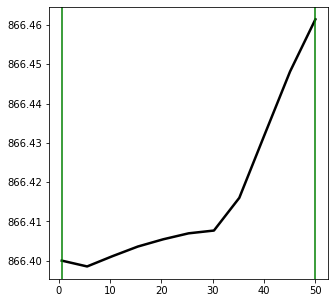

In [13]:
LI_test(like, samples[:, 2], bin_n=10, verbose=True)

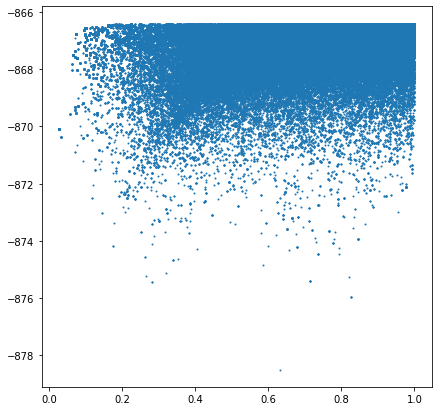

In [11]:
import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000


fig, ax = plt.subplots(1, 1, figsize=(7, 7))
#print(samples[:, 0].shape, like.shape)
ax.scatter(samples[:, 0], like, s=1)

In [16]:
def FSE_f_gamma_rs(filepath, nBDs, rel_unc, relM, ex, rank=100, PE="median"):   
    # grid points                                                               
    f     = 1.                                                                      
    rs    = np.array([20.])                                                
    gamma = np.array([1])                         
                                                                                    
    FSE_1 = []; FSE_2 = []; FSE_3 = []                                              
    for _rs in rs:                                                                  
        for _g in gamma:                                                            
            true = [f, _g, _rs]                                                     
            data = np.genfromtxt(filepath + "statistics_" + ex +                    
                                 ("_N%i_relunc%.2f_relM%.2f_f%.1fgamma%.1frs%.1f" 
                                  %(nBDs, rel_unc, relM, f, _g, _rs)), unpack=True)
            if PE=="median":                                                        
                pe = np.array((data[3], data[4], data[5]))                          
            elif PE=="ML":                                                          
                pe = np.array((data[15], data[16], data[17]))                       
            else:                                                                   
                sys.exit("Point estimate not implemented!")                         
            FSE_1.append(np.sqrt(1/rank*np.sum(np.power(pe[0] - true[0], 2)))/true[0])
            if np.abs(_g) < 1e-5:                                                   
                epsilon=1e-4                                                        
            else:                                                                   
                epsilon=0.                                                          
            FSE_2.append(np.sqrt(1/rank*np.sum(np.power(pe[1] - true[1], 2)))/(true[1]+epsilon))
            FSE_3.append(np.sqrt(1/rank*np.sum(np.power(pe[2] - true[2], 2)))/true[2])
                                                                                    
    xi = np.array([2.5, 7.5, 15, 25])                                               
    yi = np.array([0., 0.25, 0.75, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55])             
    xi, yi = np.meshgrid(xi, yi, indexing="ij")                                     
                                                                                    
    zi_1   = np.array(FSE_1).reshape(len(rs), len(gamma))                           
    zi_2   = np.array(FSE_2).reshape(len(rs), len(gamma))                           
    zi_3   = np.array(FSE_3).reshape(len(rs), len(gamma))                           
    # return                                                                        
    return pe, xi, yi, zi_1, zi_2, zi_3

In [31]:
pe, _, _, _, _, _ = FSE_f_gamma_rs(path, 100, 0.1, 0.1, "ex25", rank=100, PE="median")

In [32]:
print (pe.shape, pe[1])

(3, 100) [1.0476 0.942  0.8159 1.2455 1.011  1.1219 1.1283 1.2665 1.3664 0.959
 1.0358 0.8923 1.036  1.1349 0.9497 0.7213 1.0268 1.1965 1.1331 0.9108
 1.2336 1.0369 1.2804 0.9644 0.9902 1.0175 0.6718 1.0662 1.1549 1.2671
 0.8988 0.9748 1.2136 1.0897 1.1343 1.0291 1.0517 1.4166 1.1828 1.0196
 0.9398 0.7995 0.9196 1.1219 1.285  1.0792 0.8853 1.0905 1.018  1.1795
 1.1646 1.0875 1.2354 0.91   1.0746 1.0745 0.9866 0.729  1.0786 0.9108
 0.8468 1.2437 1.1242 1.0392 1.1323 0.9906 0.7748 1.1534 1.0529 1.1469
 1.641  1.0949 1.3548 1.1297 1.1102 1.0804 1.044  1.1837 1.0624 1.0118
 1.0932 1.1077 1.1347 0.8685 1.3373 1.2879 1.1565 1.0628 1.2111 1.1866
 0.7483 1.1276 1.4054 0.7443 1.2084 1.2123 0.9245 1.2064 1.0371 1.1155]


In [33]:
np.sqrt(1/100*np.sum(np.power(pe[1] - 1., 2)))

0.1792928648887066

xvals =  (4.922753073810515e-05, 2.224383319197255)
yvals =  (0.0, 1.0999999999999213)
4.922753073810515e-05 2.224383319197255    -0.42957571067294964 1.0
0.243870576864742 49.99905197279563    0.9165547924228008 1.0
0.0006990402546363517 0.9999905832354677    0.7611694909678874 1.0
0.9861131931492482 0.6619882846653002 9.117964238681903


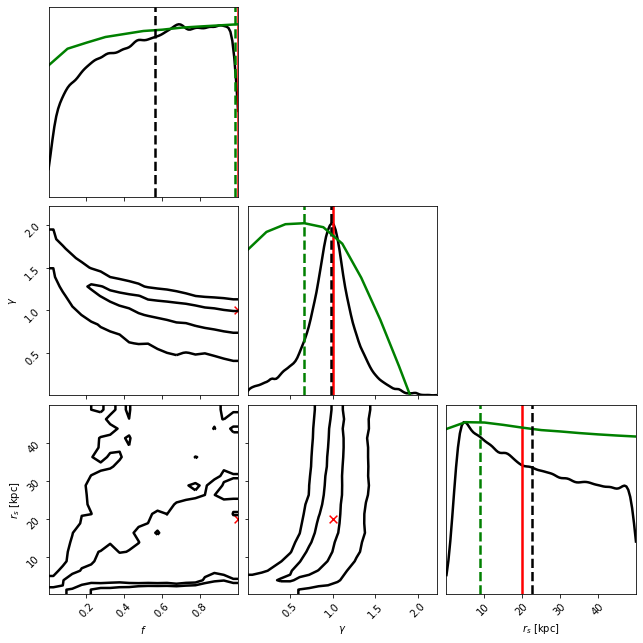

In [6]:
nBDs = 100; relT = 0.10; relM = 0.10; ex = "ex25"
f_true=1.; rs_true = 20.; gamma_true=1.

_path   = "/hdfs/local/mariacst/exoplanets/results/final_round/"
_file   = open(_path + 
               "likelihood/all_unc/velocity/v200/N%irelT%.2frelM%.2f/like_" %(nBDs, relT, relM) +
               ex + 
               "_N%i_relunc%.2f_relM%.2f_f%.1fgamma%.1frs%.1fv32" %(nBDs, relT, relM, f_true, gamma_true, rs_true),
               "rb") 
like    = pickle.load(_file)
_file   = open(_path + 
               "all_unc/velocity/v200/N%irelT%.2frelM%.2f/posterior_" %(nBDs, relT, relM) +
               ex + 
               "_N%i_relunc%.2f_relM%.2f_f%.1fgamma%.1frs%.1fv32" %(nBDs, relT, relM, f_true, gamma_true, rs_true),
               "rb") 
samples = pickle.load(_file)

smooth=0.5
fig, axes = corner(samples, levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
                   plot_density=False, fill_contours=False, smooth=smooth)

# plot KDE smoothed version of distributions
for axidx, samps in zip([0, 4, 8], samples.T):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim()
    xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="k", lw=2.5) 
    if axidx==4:
        #print(xvals, kde(xvals)/np.max(kde(xvals)))
        xvals = fig.axes[axidx].get_xlim()
        yvals = fig.axes[axidx].get_ylim()
        print("xvals = ", xvals)
        print("yvals = ", yvals)

ML = samples[np.argmax(like)]
axes[0, 0].axvline(ML[0], ls="--", lw=2.5, color="g"); axes[0, 0].axvline(f_true, color="r", ls="-", lw=2.5)
axes[1, 1].axvline(ML[1], ls="--", lw=2.5, color="g"); axes[1, 1].axvline(gamma_true, color="r", ls="-", lw=2.5)
axes[2, 2].axvline(ML[2], ls="--", lw=2.5, color="g"); axes[2, 2].axvline(rs_true, color="r", ls="-", lw=2.5)

axes[1, 1].axvline(0.9748, color="k", ls="--", lw=2.5)
bin_n=10
x = binned_statistic(samples[:, 1], like, 'max', bins=bin_n)[1] 
y = binned_statistic(samples[:, 1], like, 'max', bins=bin_n+1)[0]
#print(y)
y = y - np.max(y) + 1
print(np.min(x), np.max(x), "  ", np.min(y), np.max(y))
axes[1, 1].plot(x, y, ls="-", color="green", lw=2.5)

x = binned_statistic(samples[:, 2], like, 'max', bins=bin_n)[1] 
y = binned_statistic(samples[:, 2], like, 'max', bins=bin_n+1)[0]
#print(y)
y = y - np.max(y) + 1
print(np.min(x), np.max(x), "  ", np.min(y), np.max(y))
axes[2, 2].plot(x, y, ls="-", color="green", lw=2.5)
axes[2, 2].axvline(22.6111, color="k", ls="--", lw=2.5)

x = binned_statistic(samples[:, 0], like, 'max', bins=bin_n)[1] 
y = binned_statistic(samples[:, 0], like, 'max', bins=bin_n+1)[0]
#print(y)
y = y - np.max(y) + 1
print(np.min(x), np.max(x), "  ", np.min(y), np.max(y))
axes[0, 0].plot(x, y, ls="-", color="green", lw=2.5)
axes[0, 0].axvline(0.5637, color="k", ls="--", lw=2.5)

axes[1, 0].scatter(f_true, gamma_true, marker="x", color="red", s=60)
axes[2, 0].scatter(f_true, rs_true, marker="x", color="red", s=60)
axes[2, 1].scatter(gamma_true, rs_true, marker="x", color="red", s=60)

axes[1, 0].set_ylabel(r"$\gamma$")
axes[2, 0].set_xlabel(r"$f$")
axes[2, 0].set_ylabel(r"$r_s$ [kpc]")
axes[2, 1].set_xlabel(r"$\gamma$")
axes[2, 2].set_xlabel(r"$r_s$ [kpc]")

print(ML[0], ML[1], ML[2])

In [63]:
print (pe[:, 31])

[ 0.5637  0.9748 22.6111]


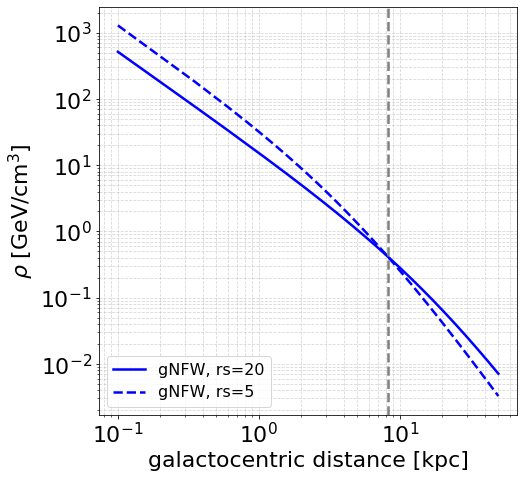

In [68]:
from utils import gNFW_rho

r  = np.linspace(0.1, 50, 200)
R0 = 8.178

rho1 = gNFW_rho(R0, r, [1.5, 20., 0.42])
rho2 = gNFW_rho(R0, r, [1.5, 5., 0.42])

fig, ax = plt.subplots(1, 1, figsize=(7.5, 7.5))
ax.plot(r, rho1, color="blue", lw=2.5, label="gNFW, rs=20")
ax.plot(r, rho2, color="blue", lw=2.5, ls="--", label=r"gNFW, rs=5")

ax.axvline(R0, ls="--", color="grey", lw=2.5)

ax.grid(which="both", ls="--", alpha=0.5)
ax.set_ylabel(r"$\rho$ $\rm [GeV/cm^3]$")
ax.set_xlabel("galactocentric distance [kpc]")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend(fontsize=16)

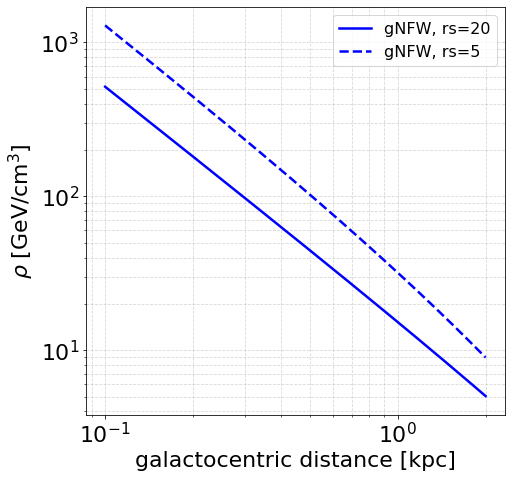

In [69]:
from utils import gNFW_rho

r  = np.linspace(0.1, 2, 200)
R0 = 8.178

rho1 = gNFW_rho(R0, r, [1.5, 20., 0.42])
rho2 = gNFW_rho(R0, r, [1.5, 5., 0.42])

fig, ax = plt.subplots(1, 1, figsize=(7.5, 7.5))
ax.plot(r, rho1, color="blue", lw=2.5, label="gNFW, rs=20")
ax.plot(r, rho2, color="blue", lw=2.5, ls="--", label=r"gNFW, rs=5")

#ax.axvline(R0, ls="--", color="grey", lw=2.5)

ax.grid(which="both", ls="--", alpha=0.5)
ax.set_ylabel(r"$\rho$ $\rm [GeV/cm^3]$")
ax.set_xlabel("galactocentric distance [kpc]")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend(fontsize=16)

In [16]:
def FSE_f(filepath, nBDs, rel_unc, relM, ex, _g, _rs, rank=100, PE="median"):   
    # grid points                                                               
    f     = 1.                                                                      
    rs    = np.array([20.])                                                
    gamma = np.array([1])                         
                                                                                    
    FSE_1 = []; FSE_2 = []; FSE_3 = []                                              
   
            
    true = [f, _g, _rs]                                                     
    data = np.genfromtxt(filepath + "statistics_" + ex +                    
                         ("_N%i_relunc%.2f_relM%.2f_f%.1fgamma%.1frs%.1f" 
                          %(nBDs, rel_unc, relM, f, _g, _rs)), unpack=True)
    if PE=="median":                                                        
        pe = np.array((data[3], data[4], data[5]))                          
    elif PE=="ML":                                                          
        pe = np.array((data[15], data[16], data[17]))                       
    else:                                                                   
        sys.exit("Point estimate not implemented!")                         
    FSE_1.append((pe[0] - true[0])/true[0])
    if np.abs(_g) < 1e-5:                                                   
        epsilon=1e-4                                                        
    else:                                                                   
        epsilon=0.                                                          
    FSE_2.append((pe[1] - true[1])/(true[1]+epsilon))
    FSE_3.append((pe[2] - true[2])/true[2])
                                                                                                             
    # return                                                                        
    return FSE_1, FSE_2, FSE_3

Text(0.5, 0, '$\\frac{\\gamma^{true}-\\gamma^{reconst.}}{\\gamma^{true}}$')

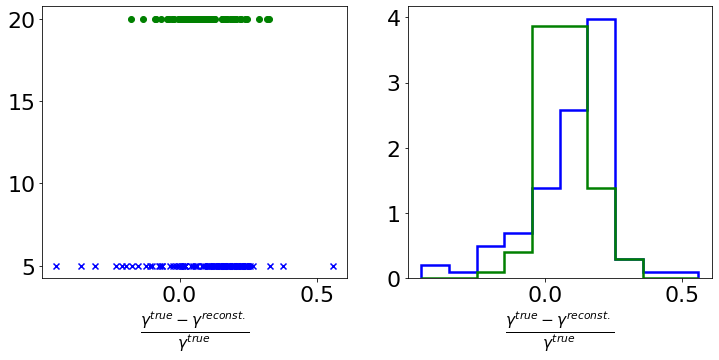

In [30]:
_, FSE_2_5, _  = FSE_f(path, 100, 0.1, 0.1, "ex25", 1.5, 5., rank=100, PE="median")
_, FSE_2_20, _ = FSE_f(path, 100, 0.1, 0.1, "ex25", 1.5, 20., rank=100, PE="median")


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(FSE_2_5, np.ones(np.shape(FSE_2_5))*5., marker="x", color="blue")
ax[0].scatter(FSE_2_20, np.ones(np.shape(FSE_2_20))*20, marker="o", color="green")

_, bins, _= ax[1].hist(FSE_2_5, color="blue", linewidth=2.5, histtype="step", density=True) 
# tendría que normalizarlo con respecto a 1!!!!
ax[1].hist(FSE_2_20, color="green", linewidth=2.5, histtype="step", bins=bins, density=True)

ax[0].set_xlabel(r"$\frac{\gamma^{true}-\gamma^{reconst.}}{\gamma^{true}}$")
ax[1].set_xlabel(r"$\frac{\gamma^{true}-\gamma^{reconst.}}{\gamma^{true}}$")

## Starting from the beginning...

In [3]:
import mock_generation
import imp
imp.reload(mock_generation)

from mock_generation import mock_population_all
from utils import temperature_withDM, heat
from scipy.interpolate import griddata
from astropy.constants import R_jup, M_sun

**Only uncertainties in T**

In [4]:
nBDs = 100; relT=0.1; 
f_true=1.; gamma_true=1.5; rs_true=20.;
rho0=0.42

def residual(p, robs, Tobs, sigma_Tobs, heat_int, mass):                   
    f, gamma, rs = p                                                            
    Tmodel = temperature_withDM(robs, heat_int, f=f, M=mass*M_sun.value,        
                                parameters=[gamma, rs, rho0])                   
    return -0.5*np.sum(((Tmodel-Tobs)/sigma_Tobs)**2.)

In [18]:
#np.random.seed(21)
robs, Tobs, sigmaTobs, mass, ages = mock_population_all(nBDs, relT, 0., 0., 0., f_true, gamma_true, 
                                                        rs_true, rho0_true=rho0) 

# Load theoretical cooling model
path = "./data/"                                                                
data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)            
points = np.transpose(data[0:2, :])                                             
values = data[2]  
# calculate predictic intrinsic heat flow for mock BDs                         
xi = np.transpose(np.asarray([ages, mass]))                                     
Teff     = griddata(points, values, xi)                                         
heat_int = heat(Teff, np.ones(len(Teff))*R_jup.value)

In [33]:
relT

0.1

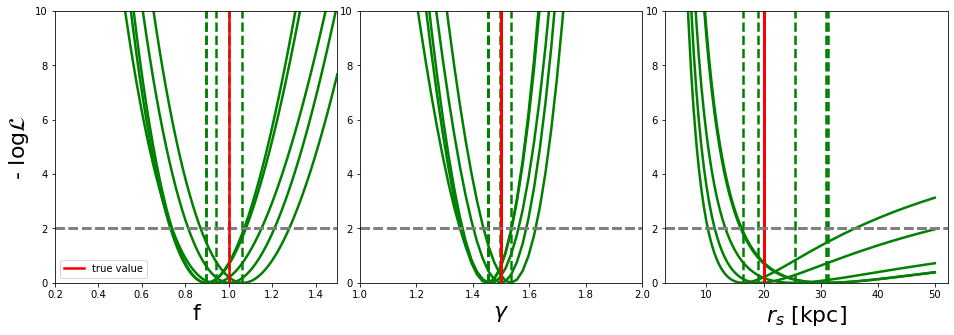

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

for k in range(5):
    
    #np.random.seed(21)
    robs, Tobs, sigmaTobs, mass, ages = mock_population_all(nBDs, relT, 0., 0., 0., f_true, gamma_true, 
                                                            rs_true, rho0_true=rho0) 
    
    # Load theoretical cooling model
    path = "./data/"                                                                
    data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)            
    points = np.transpose(data[0:2, :])                                             
    values = data[2]  
    # calculate predictic intrinsic heat flow for mock BDs                         
    xi = np.transpose(np.asarray([ages, mass]))                                     
    Teff     = griddata(points, values, xi)                                         
    heat_int = heat(Teff, np.ones(len(Teff))*R_jup.value)
    
    Npoints = 100
    
    #ax[0].set_title("Vary $f$")
    f      = np.linspace(0, 1.5, Npoints)
    like_f = np.zeros(Npoints)
    for i in range(Npoints):
        like_f[i] = residual([f[i], gamma_true, rs_true], robs, Tobs, sigmaTobs, heat_int, mass)
    ax[0].plot(f, -like_f+np.max(like_f), color="green", lw=2.5); ax[0].axvline(f[np.argmax(like_f)], color="green", lw=2.5, ls="--")
    ax[0].set_ylim(0, 10); ax[0].set_xlim(0.2, 1.5)
    ax[0].axhline(2, color="grey", ls="--", lw=2.5)
    
    #ax[1].set_title("Vary $\gamma$")
    gamma      = np.linspace(0, 2., Npoints)
    like_gamma = np.zeros(Npoints)
    for i in range(Npoints):
        like_gamma[i] = residual([f_true, gamma[i], rs_true], robs, Tobs, sigmaTobs, heat_int, mass)
    ax[1].plot(gamma, -like_gamma+np.max(like_gamma), color="green", lw=2.5); 
    ax[1].axvline(gamma[np.argmax(like_gamma)], color="green", lw=2.5, ls="--"); 
    ax[1].axvline(gamma_true, color="red", lw=2.5); ax[1].set_ylim(0, 10); ax[1].set_xlim(1., 2.)
    ax[1].axhline(2, color="grey", ls="--", lw=2.5)
    
    #ax[2].set_title("Vary $r_s$")
    rs      = np.linspace(5., 50., Npoints)
    like_rs = np.zeros(Npoints)
    for i in range(Npoints):
        like_rs[i] = residual([f_true, gamma_true, rs[i]], robs, Tobs, sigmaTobs, heat_int, mass)
    ax[2].plot(rs, -like_rs+np.max(like_rs), color="green", lw=2.5); 
    ax[2].axvline(rs[np.argmax(like_rs)], color="green", lw=2.5, ls="--"); 
    ax[2].axvline(rs_true, color="red", lw=2.5); ax[2].set_ylim(0, 10)
    ax[2].axhline(2, color="grey", ls="--", lw=2.5)

ax[0].axvline(f_true, color="red", lw=2.5, label="true value")
ax[0].legend()
ax[0].set_ylabel(r"- log$\mathcal{L}$", fontsize=22)
ax[0].set_xlabel("f", fontsize=22)
ax[1].set_xlabel(r"$\gamma$", fontsize=22)
ax[2].set_xlabel(r"$r_s$ [kpc]", fontsize=22)
fig.subplots_adjust(wspace=0.08)

fig.savefig("logL_relT0.10_relX0.0.pdf", bbox_inches="tight")

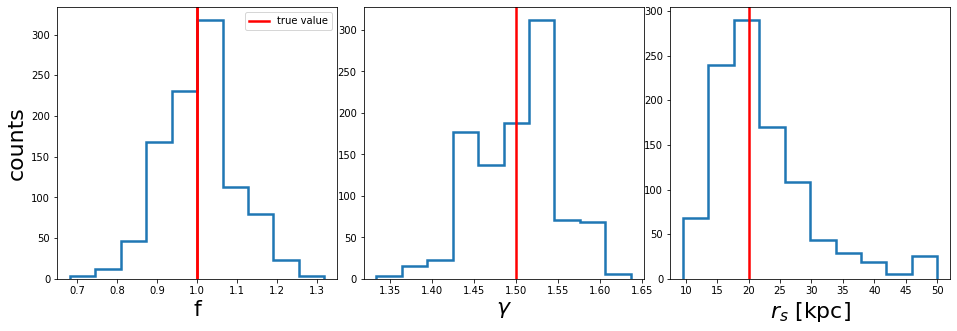

In [31]:
f_ML, gamma_ML, rs_ML = np.genfromtxt("../python/checks/check_likelihood_onlyTunc.dat", unpack=True)
    
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].hist(f_ML, histtype="step", linewidth=2.5); ax[1].hist(gamma_ML, histtype="step", linewidth=2.5); 
ax[2].hist(rs_ML, histtype="step", linewidth=2.5);
ax[0].axvline(f_true, color="red", lw=2.5); ax[1].axvline(gamma_true, color="red", lw=2.5);
ax[2].axvline(rs_true, color="red", lw=2.5);

ax[0].axvline(f_true, color="red", lw=2.5, label="true value")
ax[0].legend()
ax[0].set_ylabel(r"counts", fontsize=22)
ax[0].set_xlabel("f", fontsize=22)
ax[1].set_xlabel(r"$\gamma$", fontsize=22)
ax[2].set_xlabel(r"$r_s$ [kpc]", fontsize=22)
fig.subplots_adjust(wspace=0.095)

fig.savefig("histML_relT0.10_relX0.0.pdf", bbox_inches="tight")

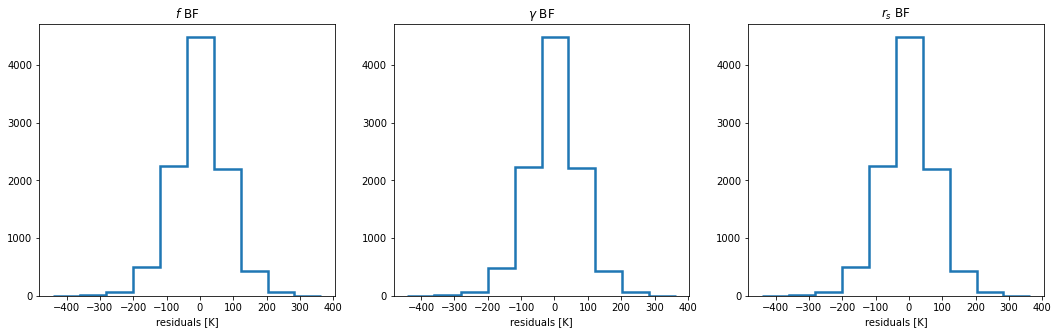

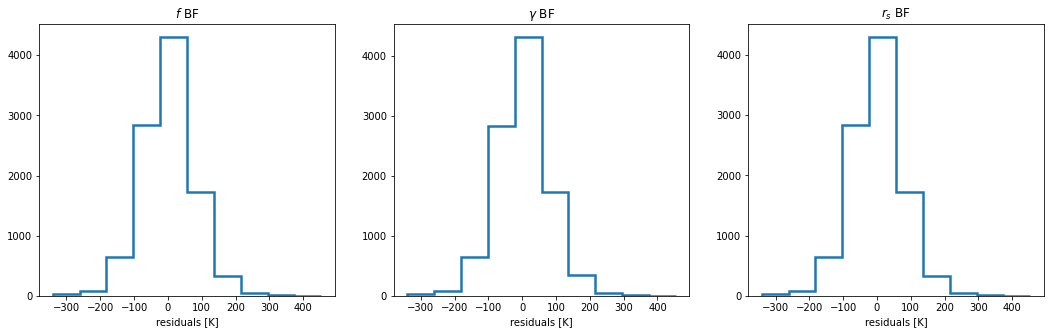

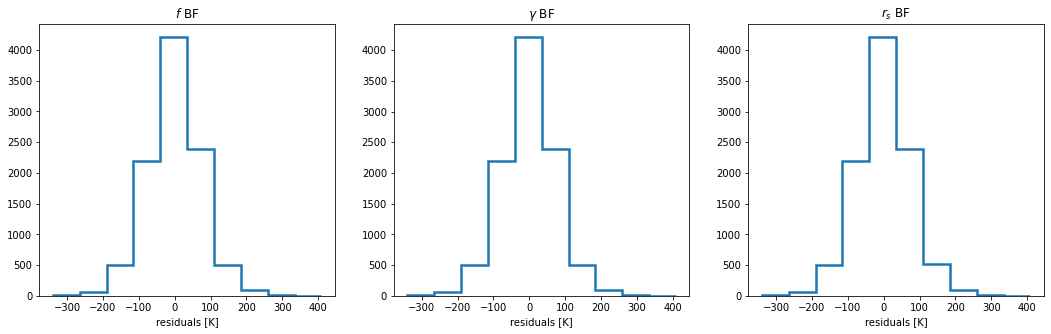

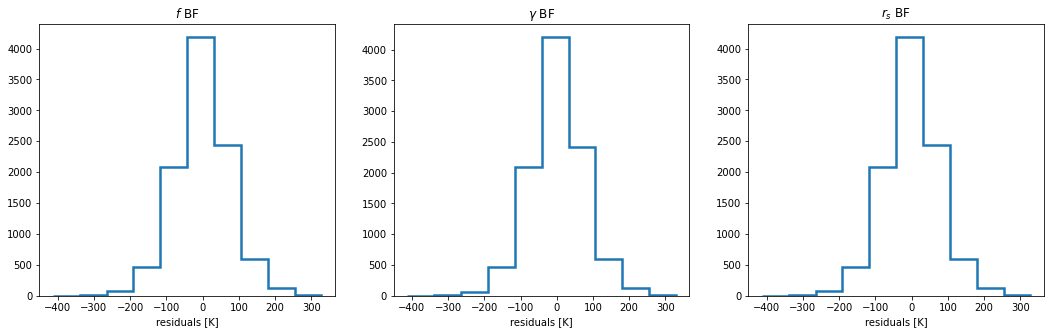

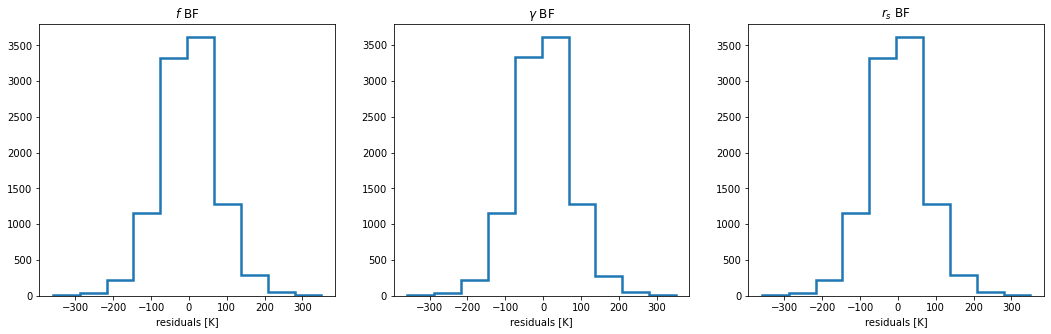

In [10]:
for k in range(5):
    
    #np.random.seed(21)
    robs, Tobs, sigmaTobs, mass, ages = mock_population_all(10000, relT, 0., 0., 0., f_true, gamma_true, 
                                                            rs_true, rho0_true=rho0) 
    
    # Load theoretical cooling model
    path = "./data/"                                                                
    data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)            
    points = np.transpose(data[0:2, :])                                             
    values = data[2]  
    # calculate predictic intrinsic heat flow for mock BDs                         
    xi = np.transpose(np.asarray([ages, mass]))                                     
    Teff     = griddata(points, values, xi)                                         
    heat_int = heat(Teff, np.ones(len(Teff))*R_jup.value)
    
    Npoints = 100
    
    f          = np.linspace(0, 1.5, Npoints)
    gamma      = np.linspace(0, 2., Npoints)
    rs         = np.linspace(5., 50., Npoints)
    
    like_f     = np.zeros(Npoints)
    like_gamma = np.zeros(Npoints)
    like_rs    = np.zeros(Npoints)
    
    for i in range(Npoints):
        like_f[i]     = residual([f[i], gamma_true, rs_true], robs, Tobs, sigmaTobs, heat_int, mass)
        like_gamma[i] = residual([f_true, gamma[i], rs_true], robs, Tobs, sigmaTobs, heat_int, mass)
        like_rs[i]   = residual([f_true, gamma_true, rs[i]], robs, Tobs, sigmaTobs, heat_int, mass)
    
    f_ML     = f[np.argmax(like_f)]
    gamma_ML = gamma[np.argmax(like_gamma)]
    rs_ML    = rs[np.argmax(like_rs)]
    
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    ax[0].set_title("$f$ BF")     
    Tmodel = temperature_withDM(robs, heat_int, f=f_ML, M=mass*M_sun.value, 
                                parameters=[gamma_true, rs_true, 0.42]) 
    ax[0].hist((Tobs-Tmodel), histtype="step", linewidth=2.5);
    ax[0].set_xlabel("residuals [K]")
    
    ax[1].set_title("$\gamma$ BF")
    Tmodel = temperature_withDM(robs, heat_int, f=f_true, M=mass*M_sun.value, 
                                parameters=[gamma_ML, rs_true, 0.42]) 
    ax[1].hist((Tobs-Tmodel), histtype="step", linewidth=2.5);
    ax[1].set_xlabel("residuals [K]")
    
    ax[2].set_title("$r_s$ BF")
    Tmodel = temperature_withDM(robs, heat_int, f=f_true, M=mass*M_sun.value, 
                                parameters=[gamma_true, rs_ML, 0.42]) 
    ax[2].hist((Tobs-Tmodel), histtype="step", linewidth=2.5);
    ax[2].set_xlabel("residuals [K]")

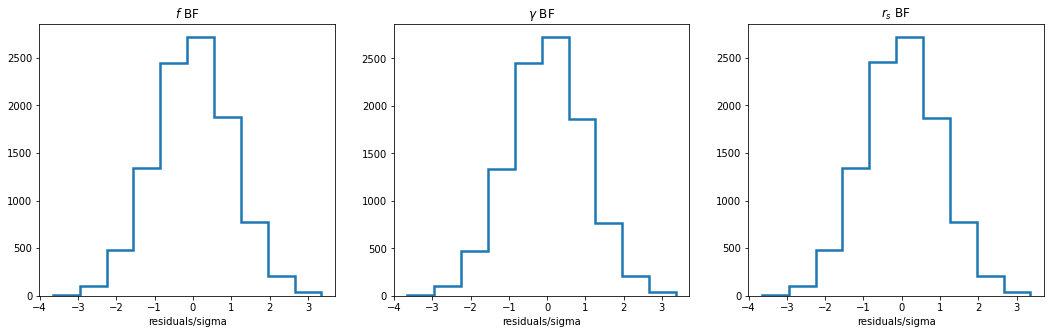

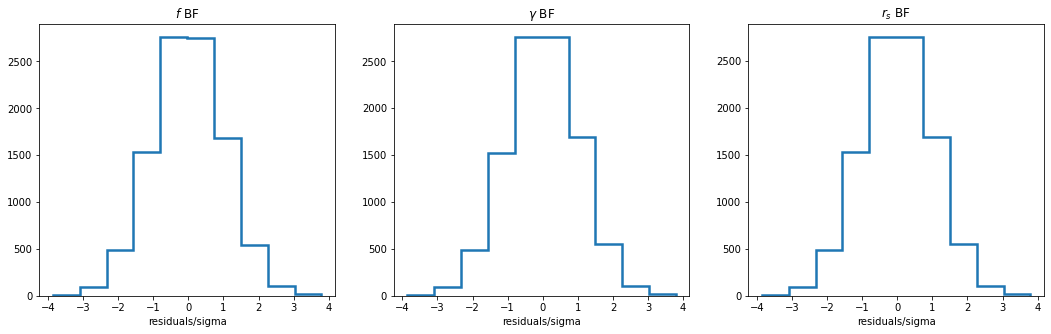

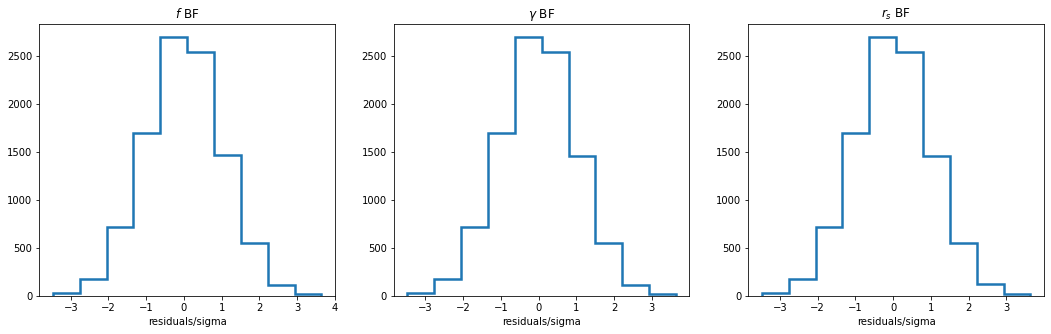

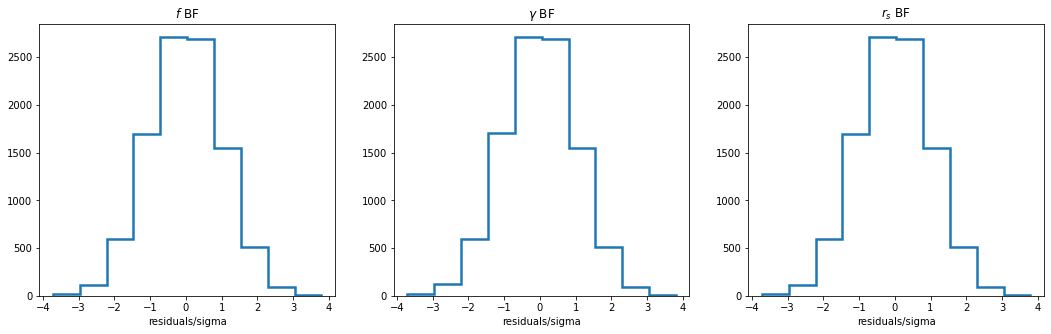

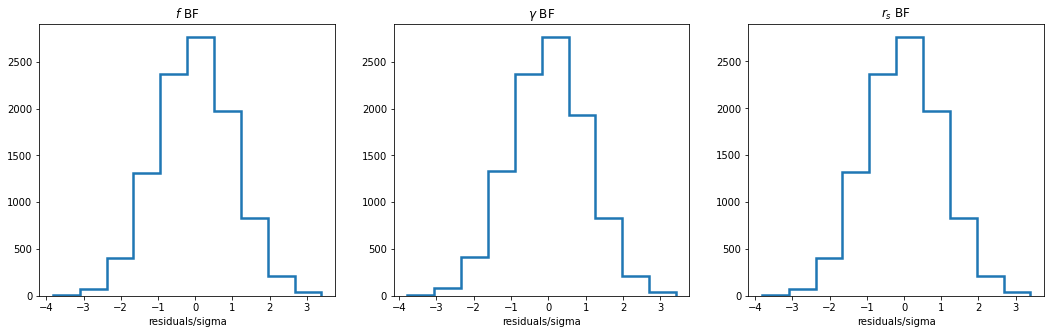

In [7]:
for k in range(5):
    
    #np.random.seed(21)
    robs, Tobs, sigmaTobs, mass, ages = mock_population_all(10000, relT, 0., 0., 0., f_true, gamma_true, 
                                                            rs_true, rho0_true=rho0) 
    
    # Load theoretical cooling model
    path = "./data/"                                                                
    data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)            
    points = np.transpose(data[0:2, :])                                             
    values = data[2]  
    # calculate predictic intrinsic heat flow for mock BDs                         
    xi = np.transpose(np.asarray([ages, mass]))                                     
    Teff     = griddata(points, values, xi)                                         
    heat_int = heat(Teff, np.ones(len(Teff))*R_jup.value)
    
    Npoints = 100
    
    f          = np.linspace(0, 1.5, Npoints)
    gamma      = np.linspace(0, 2., Npoints)
    rs         = np.linspace(5., 50., Npoints)
    
    like_f     = np.zeros(Npoints)
    like_gamma = np.zeros(Npoints)
    like_rs    = np.zeros(Npoints)
    
    for i in range(Npoints):
        like_f[i]     = residual([f[i], gamma_true, rs_true], robs, Tobs, sigmaTobs, heat_int, mass)
        like_gamma[i] = residual([f_true, gamma[i], rs_true], robs, Tobs, sigmaTobs, heat_int, mass)
        like_rs[i]   = residual([f_true, gamma_true, rs[i]], robs, Tobs, sigmaTobs, heat_int, mass)
    
    f_ML     = f[np.argmax(like_f)]
    gamma_ML = gamma[np.argmax(like_gamma)]
    rs_ML    = rs[np.argmax(like_rs)]
    
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    ax[0].set_title("$f$ BF")     
    Tmodel = temperature_withDM(robs, heat_int, f=f_ML, M=mass*M_sun.value, 
                                parameters=[gamma_true, rs_true, 0.42]) 
    ax[0].hist((Tobs-Tmodel)/sigmaTobs, histtype="step", linewidth=2.5);
    ax[0].set_xlabel("residuals/sigma")
    
    ax[1].set_title("$\gamma$ BF")
    Tmodel = temperature_withDM(robs, heat_int, f=f_true, M=mass*M_sun.value, 
                                parameters=[gamma_ML, rs_true, 0.42]) 
    ax[1].hist((Tobs-Tmodel)/sigmaTobs, histtype="step", linewidth=2.5);
    ax[1].set_xlabel("residuals/sigma")
    
    ax[2].set_title("$r_s$ BF")
    Tmodel = temperature_withDM(robs, heat_int, f=f_true, M=mass*M_sun.value, 
                                parameters=[gamma_true, rs_ML, 0.42]) 
    ax[2].hist((Tobs-Tmodel)/sigmaTobs, histtype="step", linewidth=2.5);
    ax[2].set_xlabel("residuals/sigma")

**Adding uncertainties on Mass, Age and Galactocentric distance**

In [12]:
nBDs = 100; relT=0.1; 
f_true=1.; gamma_true=1.5; rs_true=20.;
rho0=0.42

In [9]:
#np.random.seed(21)
robs, Tobs, sigmaTobs, mass, ages = mock_population_all(nBDs, relT, 0.1, 0.1, 0.1, f_true, gamma_true, 
                                                        rs_true, rho0_true=rho0) 

# Load theoretical cooling model
path = "./data/"                                                                
data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)            
points = np.transpose(data[0:2, :])                                             
values = data[2]  
# calculate predictic intrinsic heat flow for mock BDs                         
xi = np.transpose(np.asarray([ages, mass]))                                     
Teff     = griddata(points, values, xi)                                         
heat_int = heat(Teff, np.ones(len(Teff))*R_jup.value)

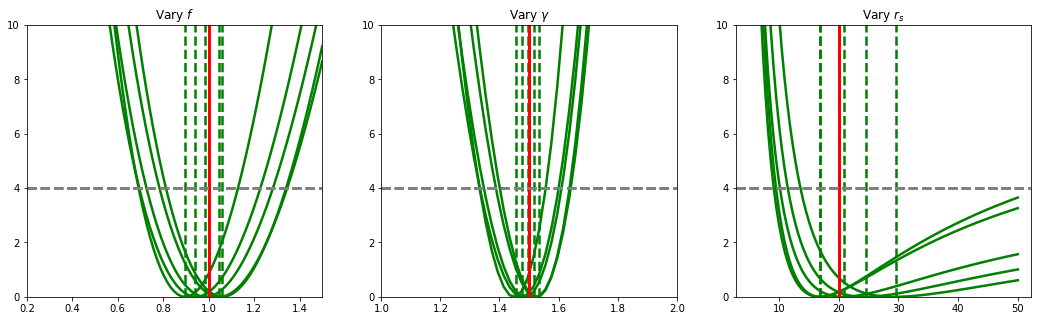

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for k in range(5):
    
    #np.random.seed(21)
    robs, Tobs, sigmaTobs, mass, ages = mock_population_all(nBDs, relT, 0.1, 0.1, 0.1, f_true, gamma_true, 
                                                            rs_true, rho0_true=rho0) 
    
    # Load theoretical cooling model
    path = "./data/"                                                                
    data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)            
    points = np.transpose(data[0:2, :])                                             
    values = data[2]  
    # calculate predictic intrinsic heat flow for mock BDs                         
    xi = np.transpose(np.asarray([ages, mass]))                                     
    Teff     = griddata(points, values, xi)                                         
    heat_int = heat(Teff, np.ones(len(Teff))*R_jup.value)
    
    Npoints = 100
    
    ax[0].set_title("Vary $f$")
    f      = np.linspace(0, 1.5, Npoints)
    like_f = np.zeros(Npoints)
    for i in range(Npoints):
        like_f[i] = residual([f[i], gamma_true, rs_true], robs, Tobs, sigmaTobs, heat_int, mass)
    ax[0].plot(f, -like_f+np.max(like_f), color="green", lw=2.5); ax[0].axvline(f[np.argmax(like_f)], color="green", lw=2.5, ls="--")
    ax[0].axvline(f_true, color="red", lw=2.5); ax[0].set_ylim(0, 10); ax[0].set_xlim(0.2, 1.5)
    ax[0].axhline(4, color="grey", ls="--", lw=2.5)
    
    
    ax[1].set_title("Vary $\gamma$")
    gamma      = np.linspace(0, 2., Npoints)
    like_gamma = np.zeros(Npoints)
    for i in range(Npoints):
        like_gamma[i] = residual([f_true, gamma[i], rs_true], robs, Tobs, sigmaTobs, heat_int, mass)
    ax[1].plot(gamma, -like_gamma+np.max(like_gamma), color="green", lw=2.5); 
    ax[1].axvline(gamma[np.argmax(like_gamma)], color="green", lw=2.5, ls="--"); 
    ax[1].axvline(gamma_true, color="red", lw=2.5); ax[1].set_ylim(0, 10); ax[1].set_xlim(1., 2.)
    ax[1].axhline(4, color="grey", ls="--", lw=2.5)
    
    ax[2].set_title("Vary $r_s$")
    rs      = np.linspace(5., 50., Npoints)
    like_rs = np.zeros(Npoints)
    for i in range(Npoints):
        like_rs[i] = residual([f_true, gamma_true, rs[i]], robs, Tobs, sigmaTobs, heat_int, mass)
    ax[2].plot(rs, -like_rs+np.max(like_rs), color="green", lw=2.5); 
    ax[2].axvline(rs[np.argmax(like_rs)], color="green", lw=2.5, ls="--"); 
    ax[2].axvline(rs_true, color="red", lw=2.5); ax[2].set_ylim(0, 10)
    ax[2].axhline(4, color="grey", ls="--", lw=2.5)

Text(0.5, 0, '$r_s$ [kpc]')

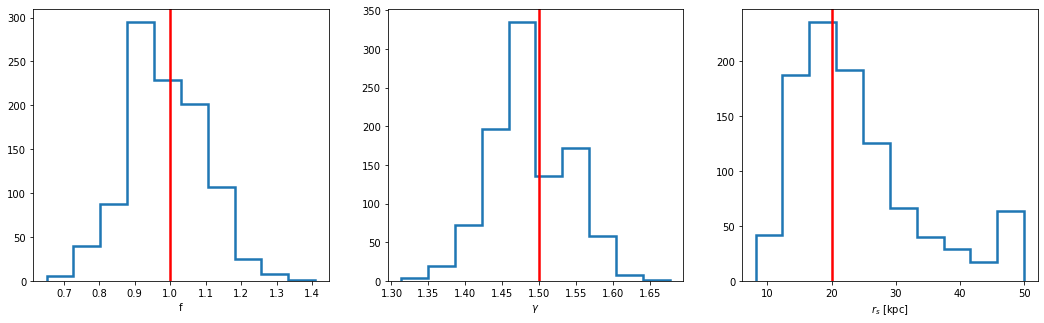

In [9]:
f_ML, gamma_ML, rs_ML = np.genfromtxt("../python/checks/check_likelihood_unc0.1.dat", unpack=True)
    
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].hist(f_ML, histtype="step", linewidth=2.5); ax[1].hist(gamma_ML, histtype="step", linewidth=2.5); 
ax[2].hist(rs_ML, histtype="step", linewidth=2.5);
ax[0].axvline(f_true, color="red", lw=2.5); ax[1].axvline(gamma_true, color="red", lw=2.5);
ax[2].axvline(rs_true, color="red", lw=2.5);

ax[0].set_xlabel("f"); ax[1].set_xlabel(r"$\gamma$"); ax[2].set_xlabel("$r_s$ [kpc]")

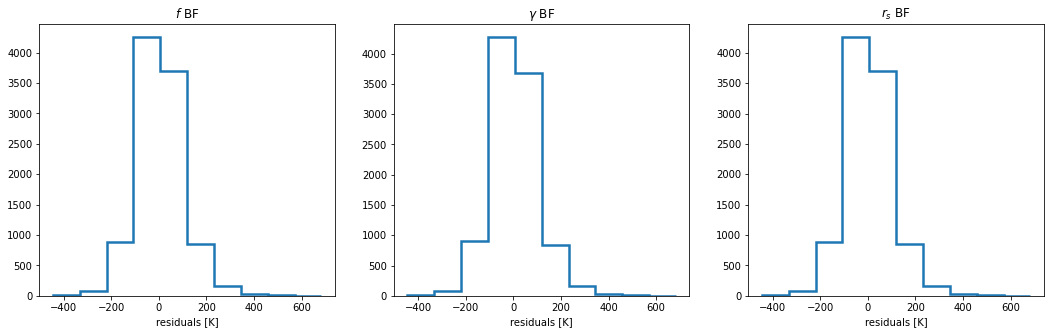

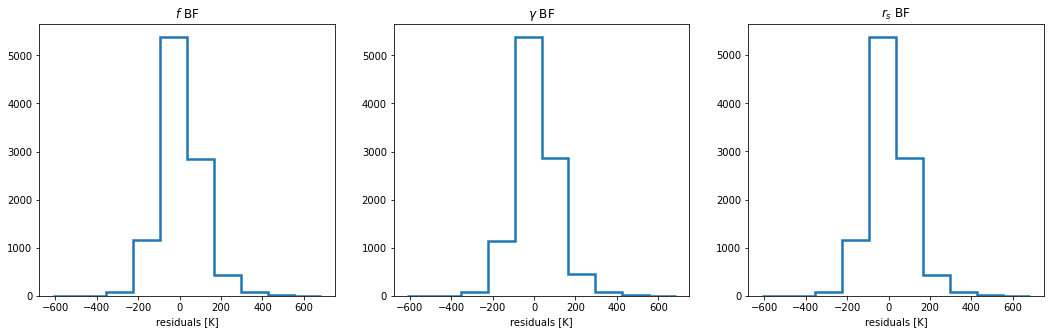

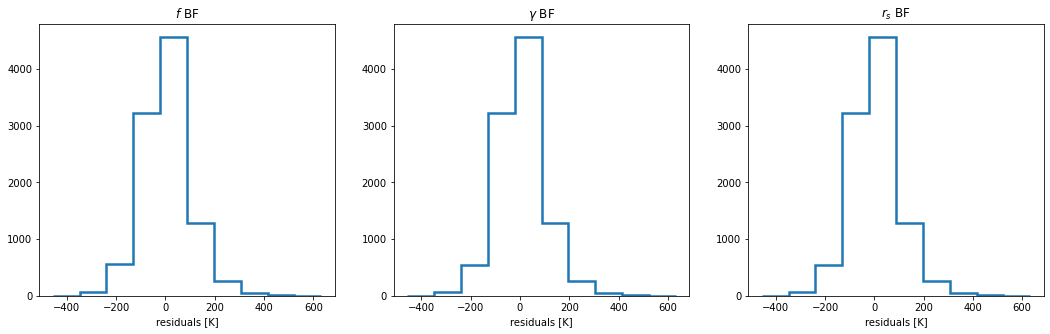

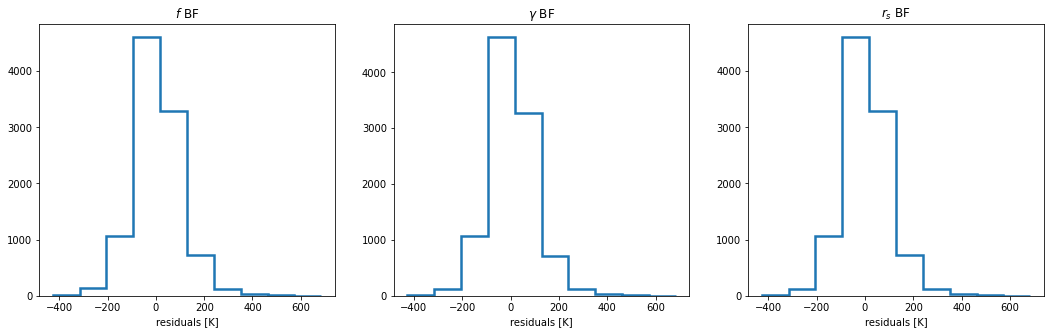

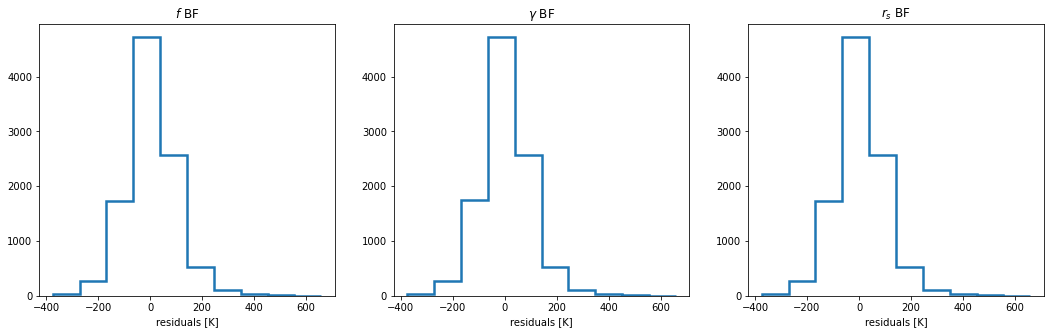

In [11]:
for k in range(5):
    
    #np.random.seed(21)
    robs, Tobs, sigmaTobs, mass, ages = mock_population_all(10000, relT, 0.1, 0.1, 0.1, f_true, gamma_true, 
                                                            rs_true, rho0_true=rho0) 
    
    # Load theoretical cooling model
    path = "./data/"                                                                
    data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)            
    points = np.transpose(data[0:2, :])                                             
    values = data[2]  
    # calculate predictic intrinsic heat flow for mock BDs                         
    xi = np.transpose(np.asarray([ages, mass]))                                     
    Teff     = griddata(points, values, xi)                                         
    heat_int = heat(Teff, np.ones(len(Teff))*R_jup.value)
    
    Npoints = 100
    
    f          = np.linspace(0, 1.5, Npoints)
    gamma      = np.linspace(0, 2., Npoints)
    rs         = np.linspace(5., 50., Npoints)
    
    like_f     = np.zeros(Npoints)
    like_gamma = np.zeros(Npoints)
    like_rs    = np.zeros(Npoints)
    
    for i in range(Npoints):
        like_f[i]     = residual([f[i], gamma_true, rs_true], robs, Tobs, sigmaTobs, heat_int, mass)
        like_gamma[i] = residual([f_true, gamma[i], rs_true], robs, Tobs, sigmaTobs, heat_int, mass)
        like_rs[i]   = residual([f_true, gamma_true, rs[i]], robs, Tobs, sigmaTobs, heat_int, mass)
    
    f_ML     = f[np.argmax(like_f)]
    gamma_ML = gamma[np.argmax(like_gamma)]
    rs_ML    = rs[np.argmax(like_rs)]
    
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    ax[0].set_title("$f$ BF")     
    Tmodel = temperature_withDM(robs, heat_int, f=f_ML, M=mass*M_sun.value, 
                                parameters=[gamma_true, rs_true, 0.42]) 
    ax[0].hist((Tobs-Tmodel), histtype="step", linewidth=2.5);
    ax[0].set_xlabel("residuals [K]")
    
    ax[1].set_title("$\gamma$ BF")
    Tmodel = temperature_withDM(robs, heat_int, f=f_true, M=mass*M_sun.value, 
                                parameters=[gamma_ML, rs_true, 0.42]) 
    ax[1].hist((Tobs-Tmodel), histtype="step", linewidth=2.5);
    ax[1].set_xlabel("residuals [K]")
    
    ax[2].set_title("$r_s$ BF")
    Tmodel = temperature_withDM(robs, heat_int, f=f_true, M=mass*M_sun.value, 
                                parameters=[gamma_true, rs_ML, 0.42]) 
    ax[2].hist((Tobs-Tmodel), histtype="step", linewidth=2.5);
    ax[2].set_xlabel("residuals [K]")

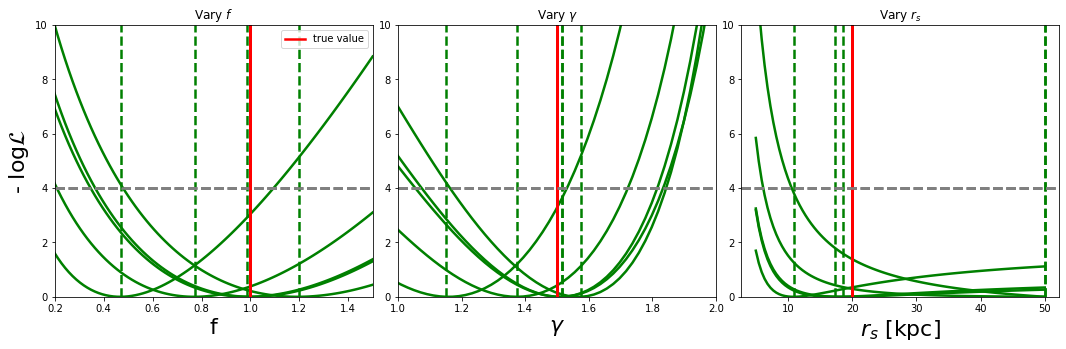

In [36]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for k in range(5):
    
    #np.random.seed(21)
    robs, Tobs, sigmaTobs, mass, ages = mock_population_all(nBDs, 0.3, 0.3, 0.3, 0.3, f_true, gamma_true, 
                                                            rs_true, rho0_true=rho0) 
    
    # Load theoretical cooling model
    path = "./data/"                                                                
    data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)            
    points = np.transpose(data[0:2, :])                                             
    values = data[2]  
    # calculate predictic intrinsic heat flow for mock BDs                         
    xi = np.transpose(np.asarray([ages, mass]))                                     
    Teff     = griddata(points, values, xi)                                         
    heat_int = heat(Teff, np.ones(len(Teff))*R_jup.value)
    
    Npoints = 100
    
    ax[0].set_title("Vary $f$")
    f      = np.linspace(0, 1.5, Npoints)
    like_f = np.zeros(Npoints)
    for i in range(Npoints):
        like_f[i] = residual([f[i], gamma_true, rs_true], robs, Tobs, sigmaTobs, heat_int, mass)
    ax[0].plot(f, -like_f+np.max(like_f), color="green", lw=2.5); ax[0].axvline(f[np.argmax(like_f)], color="green", lw=2.5, ls="--")
    ax[0].axvline(f_true, color="red", lw=2.5); ax[0].set_ylim(0, 10); ax[0].set_xlim(0.2, 1.5)
    ax[0].axhline(4, color="grey", ls="--", lw=2.5)
    
    
    ax[1].set_title("Vary $\gamma$")
    gamma      = np.linspace(0, 2., Npoints)
    like_gamma = np.zeros(Npoints)
    for i in range(Npoints):
        like_gamma[i] = residual([f_true, gamma[i], rs_true], robs, Tobs, sigmaTobs, heat_int, mass)
    ax[1].plot(gamma, -like_gamma+np.max(like_gamma), color="green", lw=2.5); 
    ax[1].axvline(gamma[np.argmax(like_gamma)], color="green", lw=2.5, ls="--"); 
    ax[1].axvline(gamma_true, color="red", lw=2.5); ax[1].set_ylim(0, 10); ax[1].set_xlim(1., 2.)
    ax[1].axhline(4, color="grey", ls="--", lw=2.5)
    
    ax[2].set_title("Vary $r_s$")
    rs      = np.linspace(5., 50., Npoints)
    like_rs = np.zeros(Npoints)
    for i in range(Npoints):
        like_rs[i] = residual([f_true, gamma_true, rs[i]], robs, Tobs, sigmaTobs, heat_int, mass)
    ax[2].plot(rs, -like_rs+np.max(like_rs), color="green", lw=2.5); 
    ax[2].axvline(rs[np.argmax(like_rs)], color="green", lw=2.5, ls="--"); 
    ax[2].axvline(rs_true, color="red", lw=2.5); ax[2].set_ylim(0, 10)
    ax[2].axhline(4, color="grey", ls="--", lw=2.5)
    
ax[0].axvline(f_true, color="red", lw=2.5, label="true value")
ax[0].legend()
ax[0].set_ylabel(r"- log$\mathcal{L}$", fontsize=22)
ax[0].set_xlabel("f", fontsize=22)
ax[1].set_xlabel(r"$\gamma$", fontsize=22)
ax[2].set_xlabel(r"$r_s$ [kpc]", fontsize=22)
fig.subplots_adjust(wspace=0.08)

fig.savefig("logL_relT0.30_relX0.3.pdf", bbox_inches="tight")

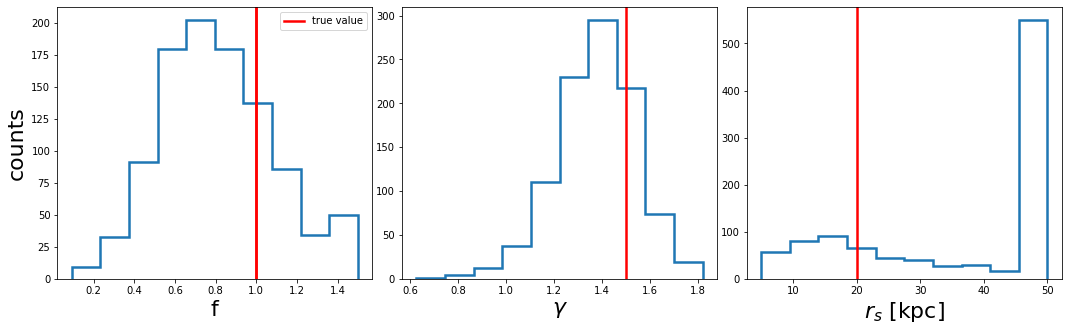

In [35]:
f_ML, gamma_ML, rs_ML = np.genfromtxt("../python/checks/check_likelihood_unc0.3.dat", unpack=True)
    
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].hist(f_ML, histtype="step", linewidth=2.5); ax[1].hist(gamma_ML, histtype="step", linewidth=2.5); 
ax[2].hist(rs_ML, histtype="step", linewidth=2.5);
ax[0].axvline(f_true, color="red", lw=2.5); ax[1].axvline(gamma_true, color="red", lw=2.5);
ax[2].axvline(rs_true, color="red", lw=2.5);

ax[0].axvline(f_true, color="red", lw=2.5, label="true value")
ax[0].legend()
ax[0].set_ylabel(r"counts", fontsize=22)
ax[0].set_xlabel("f", fontsize=22)
ax[1].set_xlabel(r"$\gamma$", fontsize=22)
ax[2].set_xlabel(r"$r_s$ [kpc]", fontsize=22)
fig.subplots_adjust(wspace=0.095)

fig.savefig("histML_relT0.30_relX0.3.pdf", bbox_inches="tight")

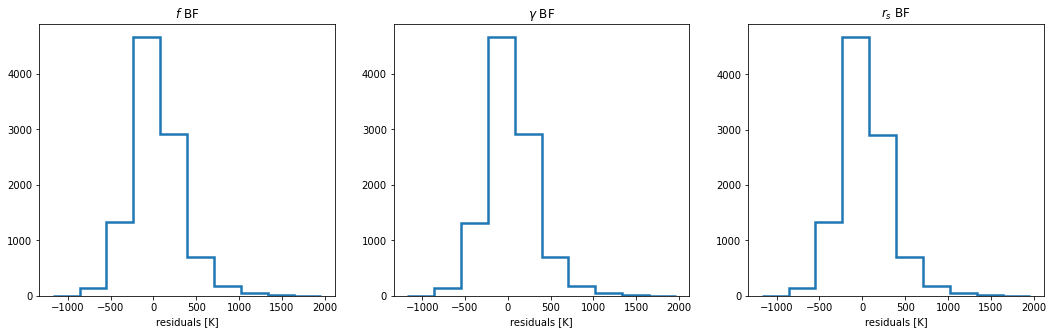

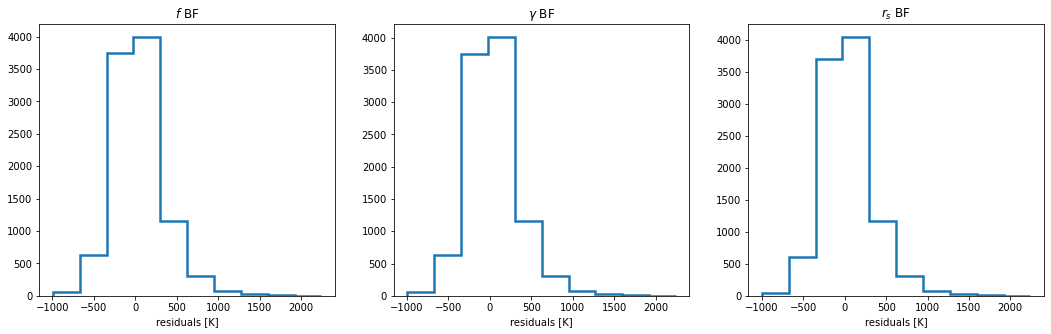

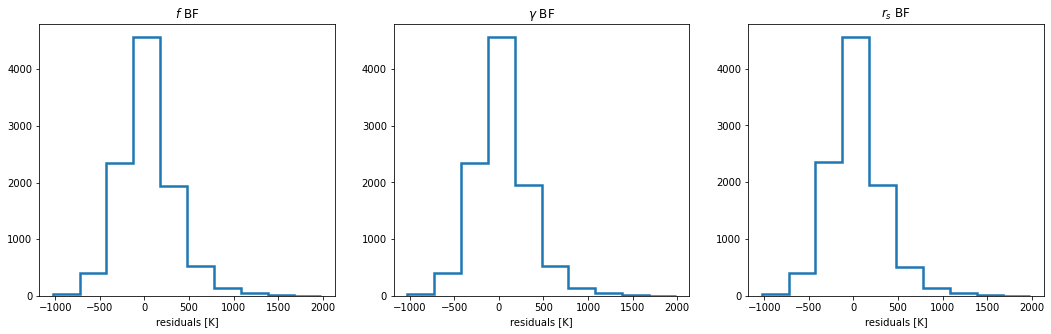

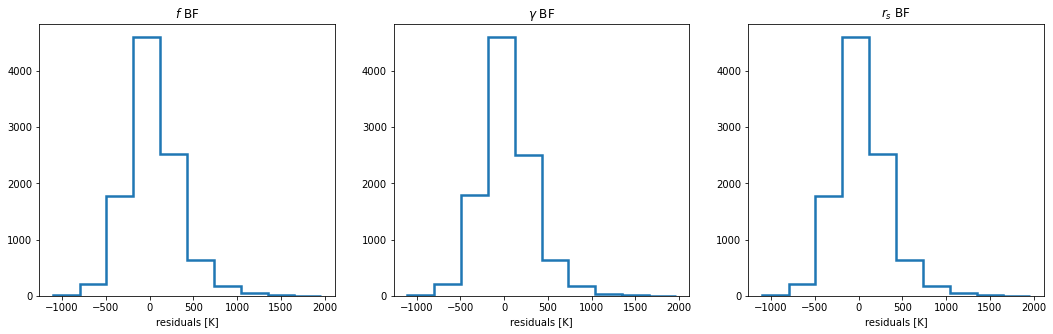

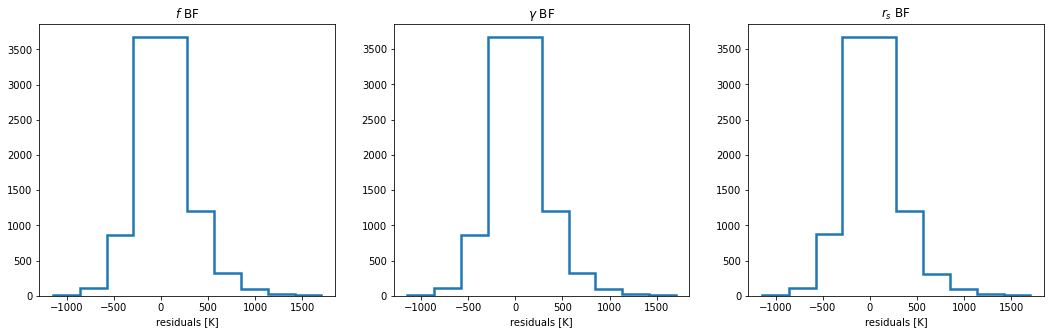

In [32]:
for k in range(5):
    
    #np.random.seed(21)
    robs, Tobs, sigmaTobs, mass, ages = mock_population_all(10000, 0.3, 0.3, 0.3, 0.3, f_true, gamma_true, 
                                                            rs_true, rho0_true=rho0) 
    
    # Load theoretical cooling model
    path = "./data/"                                                                
    data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)            
    points = np.transpose(data[0:2, :])                                             
    values = data[2]  
    # calculate predictic intrinsic heat flow for mock BDs                         
    xi = np.transpose(np.asarray([ages, mass]))                                     
    Teff     = griddata(points, values, xi)                                         
    heat_int = heat(Teff, np.ones(len(Teff))*R_jup.value)
    
    Npoints = 100
    
    f          = np.linspace(0, 1.5, Npoints)
    gamma      = np.linspace(0, 2., Npoints)
    rs         = np.linspace(5., 50., Npoints)
    
    like_f     = np.zeros(Npoints)
    like_gamma = np.zeros(Npoints)
    like_rs    = np.zeros(Npoints)
    
    for i in range(Npoints):
        like_f[i]     = residual([f[i], gamma_true, rs_true], robs, Tobs, sigmaTobs, heat_int, mass)
        like_gamma[i] = residual([f_true, gamma[i], rs_true], robs, Tobs, sigmaTobs, heat_int, mass)
        like_rs[i]   = residual([f_true, gamma_true, rs[i]], robs, Tobs, sigmaTobs, heat_int, mass)
    
    f_ML     = f[np.argmax(like_f)]
    gamma_ML = gamma[np.argmax(like_gamma)]
    rs_ML    = rs[np.argmax(like_rs)]
    
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    ax[0].set_title("$f$ BF")     
    Tmodel = temperature_withDM(robs, heat_int, f=f_ML, M=mass*M_sun.value, 
                                parameters=[gamma_true, rs_true, 0.42]) 
    ax[0].hist((Tobs-Tmodel), histtype="step", linewidth=2.5);
    ax[0].set_xlabel("residuals [K]")
    
    ax[1].set_title("$\gamma$ BF")
    Tmodel = temperature_withDM(robs, heat_int, f=f_true, M=mass*M_sun.value, 
                                parameters=[gamma_ML, rs_true, 0.42]) 
    ax[1].hist((Tobs-Tmodel), histtype="step", linewidth=2.5);
    ax[1].set_xlabel("residuals [K]")
    
    ax[2].set_title("$r_s$ BF")
    Tmodel = temperature_withDM(robs, heat_int, f=f_true, M=mass*M_sun.value, 
                                parameters=[gamma_true, rs_ML, 0.42]) 
    ax[2].hist((Tobs-Tmodel), histtype="step", linewidth=2.5);
    ax[2].set_xlabel("residuals [K]")

## Modifying the likelihood function : include "effective" uncertainty in T

In [2]:
import derivatives
import imp
imp.reload(derivatives)

from derivatives import derivativeTDM_wrt_r, derivativeTDM_wrt_M, derivativeTint_wrt_A, derivativeTint_wrt_M

### Checking the derivative of intrinsic temperature wrt to age

In [14]:
M      = np.linspace(0.013, 0.053, 4)
ages   = np.linspace(1.002, 9.998, 500)
ls     = ["-", "--", ":"]
color  = ["blue", "red", "green", "orange"]

size_baseline = 7000
h_baseline    = 1e-3

dev_baseline = {}
for m in M:
    dev_baseline[m] = derivativeTint_wrt_A(m, ages, points, values, size=size_baseline, h=h_baseline)

Text(0.5, 0, 'ages [Gyr]')

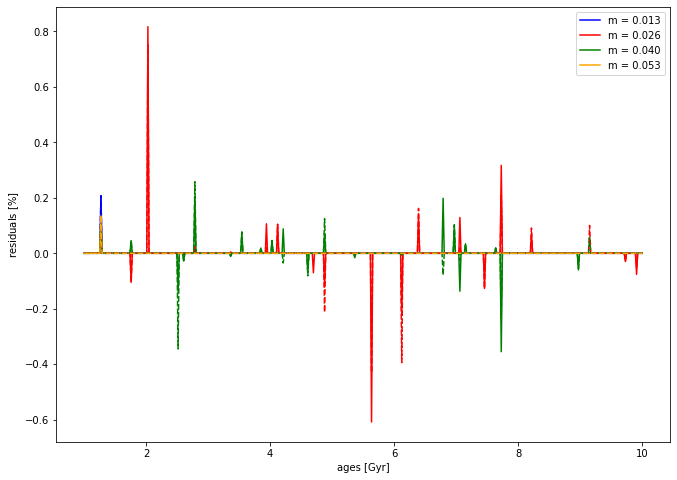

In [15]:
h = 0.001

# Effect of size
fig, ax = plt.subplots(1, 1, figsize=(11, 8))

j = 0
for s in [10000, 15000]:
    i = 0
    for m in M:
        dev = derivativeTint_wrt_A(m, ages, points, values, size=s, h=h_baseline)
        if j==0:
            ax.plot(ages, (dev-dev_baseline[m])/dev_baseline[m]*100, color=color[i], ls=ls[j], label="m = %.3f"%m)
        else:
            ax.plot(ages, (dev-dev_baseline[m])/dev_baseline[m]*100, color=color[i], ls=ls[j])
        i+=1
    j+=1
ax.legend()
ax.set_ylabel("residuals [$\%$]"); ax.set_xlabel("ages [Gyr]")

Text(0.5, 0, 'ages [Gyr]')

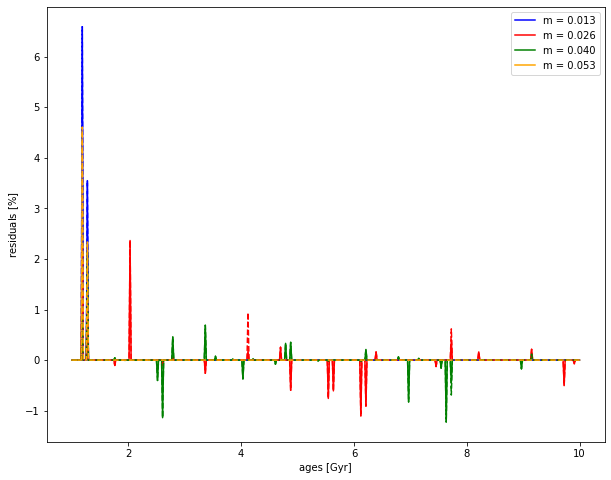

In [16]:
size   = 7000
method = "central"
# Effect of h
fig, ax = plt.subplots(1, 1, figsize=(10, 8))


j = 0
for h in [1e-4, 1e-5]:
    i = 0
    for m in M:
        dev = derivativeTint_wrt_A(m, ages, points, values, size=size_baseline, h=h)
        if j==0:
            ax.plot(ages, (dev-dev_baseline[m])/dev_baseline[m]*100, color=color[i], ls=ls[j], 
                    label="m = %.3f"%m)
        else:
            ax.plot(ages, (dev-dev_baseline[m])/dev_baseline[m]*100, color=color[i], ls=ls[j])
        i+=1
    j+=1
ax.legend()
ax.set_ylabel("residuals [$\%$]"); ax.set_xlabel("ages [Gyr]")

### Checking the derivative of intrinsic temperature wrt mass

In [17]:
M      = np.linspace(0.015, 0.051, 500)
ages   = np.linspace(1., 10., 4)
ls     = ["-", "--", ":"]
color  = ["blue", "red", "green", "orange"]

size_baseline = 7000
h_baseline    = 1e-3

dev_baseline = {}
for A in ages:
    dev_baseline[A] = derivativeTint_wrt_M(M, A, points, values, size=size_baseline, h=h_baseline)

Text(0.5, 0, 'mass [Msun]')

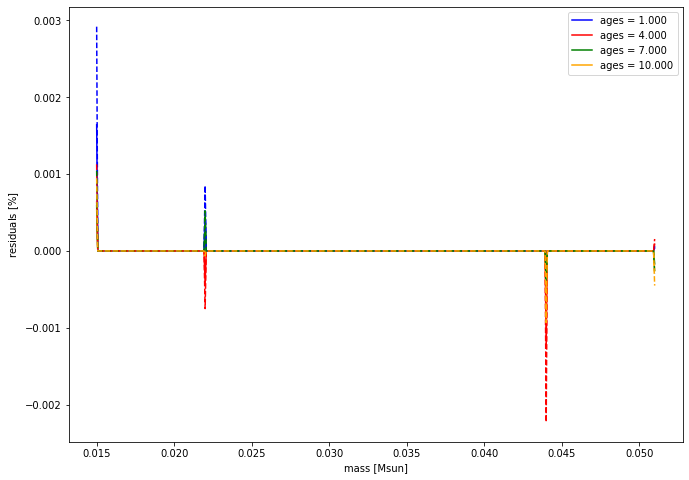

In [18]:
h = 0.001

# Effect of size
fig, ax = plt.subplots(1, 1, figsize=(11, 8))

j = 0
for s in [10000, 15000]:
    i = 0
    for A in ages:
        dev = derivativeTint_wrt_M(M, A, points, values, size=s, h=h_baseline)
        if j==0:
            ax.plot(M, (dev-dev_baseline[A])/dev_baseline[A]*100, color=color[i], ls=ls[j], label="ages = %.3f"%A)
        else:
            ax.plot(M, (dev-dev_baseline[A])/dev_baseline[A]*100, color=color[i], ls=ls[j])
        i+=1
    j+=1
ax.legend()
ax.set_ylabel("residuals [$\%$]"); ax.set_xlabel("mass [Msun]")

Text(0.5, 0, 'mass [Msun]')

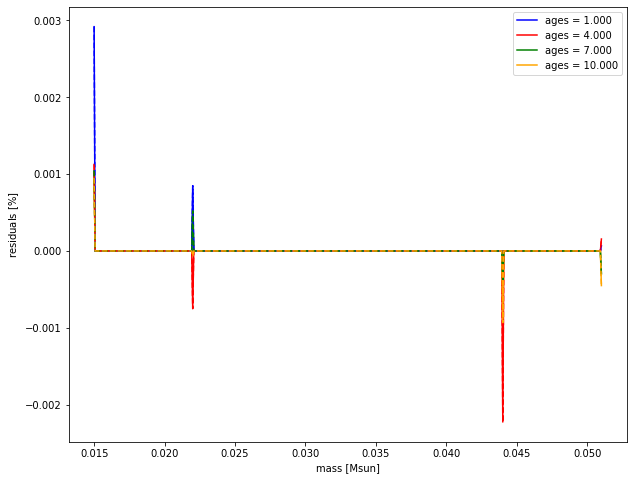

In [19]:
size   = 7000
method = "central"
# Effect of h
fig, ax = plt.subplots(1, 1, figsize=(10, 8))


j = 0
for h in [1e-4, 1e-5]:
    i = 0
    for A in ages:
        dev = derivativeTint_wrt_M(M, A, points, values, size=s, h=h_baseline)
        if j==0:
            ax.plot(M, (dev-dev_baseline[A])/dev_baseline[A]*100, color=color[i], ls=ls[j], label="ages = %.3f"%A)
        else:
            ax.plot(M, (dev-dev_baseline[A])/dev_baseline[A]*100, color=color[i], ls=ls[j])
        i+=1
    j+=1
ax.legend()
ax.set_ylabel("residuals [$\%$]"); ax.set_xlabel("mass [Msun]")

**Updated likelihood**

In [42]:
from astropy.constants import R_jup, G, sigma_sb
import derivatives
import imp
imp.reload(derivatives)
from derivatives import derivativeTint_wrt_A, derivativeTDM_wrt_r, derivativeTint_wrt_M, derivativeT_wrt_M
import utils
imp.reload(utils)
from utils import T_DM, temperature_withDM, gNFW_rho

conv_Msun_to_kg         = 1.98841e+30 # [kg/Msun]
conversion_into_K_vs_kg = 1.60217e-7                                            
conversion_into_w       = 0.16021766 
_G                      = G.value
_sigma_sb               = sigma_sb.value

**Old version**

In [ ]:
def sigma_Tmodel2(r, M, A, sigma_r, sigma_M, sigma_A, 
                  Tint, points, values, f, params, v=None, 
                  R=R_jup.value, Rsun=8.178, epsilon=1, 
                  size=7000, h=1e-3):
    """
    Return squared uncertainty in model temperature [UNITS??]
    
    Input:
        r : Galactocentric distance [kpc]
        M : mass [Msun]
        A : age [Gyr]
    
    Assumption: uncertainties in age, mass and galactocentric distance are independent
    """
    M_in_kg = M*conv_Msun_to_kg
    
    _TDM = T_DM(r, R=R, M=M_in_kg, Rsun=Rsun, f=f, params=params, v=v, epsilon=epsilon)
    Ttot = np.power(_TDM**4 + Tint**4, 0.25)

    # return
    return (np.power((Tint/Ttot)**3*derivativeTint_wrt_A(M, A, points, values, size=size, h=h)*sigma_A, 2)+ 
            
            np.power(derivativeT_wrt_M(r, M, A, Tint, _TDM, points, values, f, params, size=size, 
                                       h=h, v=v, R=R, Rsun=Rsun, epsilon=epsilon)*sigma_M, 2) + 
            
            np.power((_TDM/Ttot)**3*derivativeTDM_wrt_r(r, f, params, M, v=v, R=R, 
                                                        Rsun=Rsun, epsilon=epsilon)*sigma_r, 2))

def residual(p, robs, sigma_robs, Mobs, sigma_Mobs, Aobs, sigma_Aobs, Tobs, sigma_Tobs, 
             Tint, points, values, 
             v=None, size=7000, h=1e-3, R=R_jup.value, Rsun=8.178, rho0=0.42, epsilon=1):       
    """
    Log likelihood function (without normalization!)
    """
    # unroll free parameters
    f, gamma, rs = p         
    # model temperature [K]
    Tmodel = temperature_withDM(robs, Tint, M=Mobs*conv_Msun_to_kg, f=f, p=[gamma, rs, rho0], v=v)   
    
    _sigma_Tmodel2 = np.zeros(len(robs))
    for i in range(len(robs)):
        _sigma_Tmodel2[i] = sigma_Tmodel2(robs[i], Mobs[i], Aobs[i], 
                                          sigma_robs[i], sigma_Mobs[i], sigma_Aobs[i], 
                                          Tint[i], points, values, f, [gamma, rs, rho0], 
                                          v=v, R=R, Rsun=Rsun, epsilon=epsilon, 
                                          size=size, h=h)
    # return     
    return -0.5*np.sum((Tmodel-Tobs)**2/(sigma_Tobs**2 + _sigma_Tmodel2))

In [40]:
import mock_generation
import imp
imp.reload(mock_generation)
import utils
imp.reload(utils)
from mock_generation import mock_population_all

nBDs = 100
sigma_rel_Tobs = 0.1; sigma_rel_Mobs = 0.1; sigma_rel_Aobs = 0.1; sigma_rel_robs = 0.1
f_true = 1.; gamma_true=1.5; rs_true=20.; rho0_true=0.42

np.random.seed(21)
(robs, sigmarobs, Tobs, sigmaTobs, Mobs, 
 sigmaMobs, Aobs, sigmaAobs) = mock_population_all(nBDs, sigma_rel_Tobs, sigma_rel_Mobs, sigma_rel_robs, 
                                                sigma_rel_Aobs, f_true, gamma_true, 
                                                rs_true, rho0_true=rho0_true, Tmin=0., v=100.)

# Load theoretical cooling model
path = "./data/"                                                                
data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)            
points = np.transpose(data[0:2, :])                                             
values = data[2]  
# calculate predictic intrinsic heat flow for mock BDs                         
xi       = np.transpose(np.asarray([Aobs, Mobs]))                                     
Teff     = griddata(points, values, xi)                                         

In [44]:
i = 0
print(robs[i], Mobs[i], Aobs[i], Tobs[i])

for i in range(3):
    
    print(np.sqrt(sigma_Tmodel2(robs[i], Mobs[i], Aobs[i], sigmarobs[i], sigmaMobs[i], sigmaAobs[i], 
              Teff[i], points, values, 1., [1., 1.5, 20.], v=100., R=R_jup.value, Rsun=8.178, 
              epsilon=1., size=7000, h=1e-3)))

0.6953442363290924 0.049941133117290724 8.244060785660736 803.0052776963491
83.46477525670122
85.37928684695893
84.0355874424307


In [35]:
from derivatives import derivativeTDM_wrt_M

i = 0

def sigma_Tmodel2(r, M, A, sigma_r, sigma_M, sigma_A,                              
                  Tint, points, values, dervTint_M, dervTint_A, f, params,         
                  v=None, R=R_jup.value, Rsun=8.178, epsilon=1):                   
    """                                                                            
    Return squared uncertainty in model temperature [UNITS??]                      
                                                                                   
    Input:                                                                         
        r : Galactocentric distance [kpc]                                          
        M : mass [Msun]                                                            
        A : age [Gyr]                                                              
                                                                                   
    Assumption: uncertainties in age, mass and galactocentric distance             
        are independent                                                            
    """                                                                            
    M_in_kg = M*conv_Msun_to_kg                                                    
                                                                                   
    _TDM = T_DM(r, R=R, M=M_in_kg, Rsun=Rsun, f=f, params=params, v=v,             
                epsilon=epsilon)                                                   
    Ttot = np.power(_TDM**4 + Tint**4, 0.25)                                       
                                                                                   
    dervT_M = ((Tint/Ttot)**3*dervTint_M +                                          
               (_TDM/Ttot)**3*derivativeTDM_wrt_M(r, f, params, M, v=v, R=R,     
                                                  Rsun=Rsun,epsilon=epsilon)) 
    # return                                                                       
    return (np.power((Tint/Ttot)**3*dervTint_A*sigma_A, 2)+                        
            np.power(dervT_M*sigma_M, 2)+                                         
            np.power((_TDM/Ttot)**3*derivativeTDM_wrt_r(r, f, params, M, v=v, R=R, 
                                                        Rsun=Rsun,                 
                                                        epsilon=epsilon)*sigma_r, 2))

dervTint_A = np.ones(3)
dervTint_M = np.ones(3)
for i in range(3):
    dervTint_A[i] = derivativeTint_wrt_A(Mobs[i], Aobs[i], points, values, size=7000, h=1e-3)                    
    dervTint_M[i] = derivativeTint_wrt_M(Mobs[i], Aobs[i], points, values, size=7000, h=1e-3) 


np.sqrt(sigma_Tmodel2(robs[0:3], Mobs[0:3], Aobs[0:3], sigmarobs[0:3], sigmaMobs[0:3], sigmaAobs[0:3], 
              Teff[0:3], points, values, dervTint_M, dervTint_A, 1., [1., 1.5, 20.], v=100., 
              R=R_jup.value, Rsun=8.178, epsilon=1.))

array([83.46477526, 85.37928685, 84.03558744])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


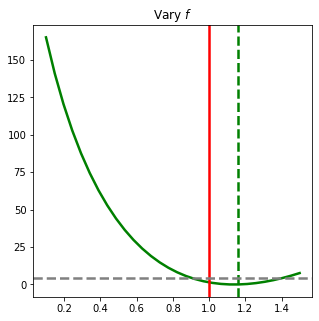

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    
Npoints = 30

ax.set_title("Vary $f$")
f      = np.linspace(0.1, 1.5, Npoints)
like_f = np.zeros(Npoints)
for i in range(Npoints):
    print(i)
    like_f[i] = residual([f[i], gamma_true, rs_true], robs, sigmarobs, Mobs, 
                         sigmaMobs, Aobs, sigmaAobs, 
                         Tobs, sigmaTobs, Teff, points, values,
                         v=100., size=7000, h=1e-3, R=R_jup.value, Rsun=8.178, 
                         rho0=0.42, epsilon=1) 
    
ax.plot(f, -like_f+np.max(like_f), color="green", lw=2.5); 
ax.axvline(f[np.argmax(like_f)], color="green", lw=2.5, ls="--")
ax.axvline(f_true, color="red", lw=2.5); #ax.set_ylim(0, 10); ax.set_xlim(0.2, 1.5)
ax.axhline(4, color="grey", ls="--", lw=2.5)

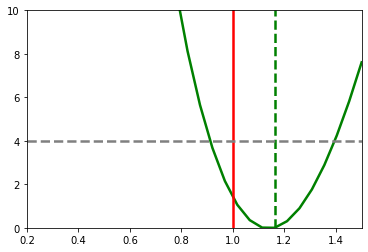

In [11]:
fig, ax = plt.subplots()

ax.plot(f, -like_f+np.max(like_f), color="green", lw=2.5); 
ax.axvline(f[np.argmax(like_f)], color="green", lw=2.5, ls="--")
ax.axvline(f_true, color="red", lw=2.5); ax.set_ylim(0, 10); ax.set_xlim(0.2, 1.5)
ax.axhline(4, color="grey", ls="--", lw=2.5)

**Check derivative wrt r**

In [32]:
from utils import temperature_withDM, gNFW_rho
from astropy.constants import R_jup, G, sigma_sb

_sigma_sb = sigma_sb.value 
conversion_into_K_vs_kg = 1.60217e-7                                            
conversion_into_w       = 0.16021766                                            
conv_Msun_to_kg         = 1.98841e+30 # [kg/Msun]  

In [33]:
# Numerical derivative
from scipy.misc import derivative

def derivando(r):    
    f=1.
    params=[1.5, 20., 0.42]
    M=0.02
    v=100.
    # return
    return (temperature_withDM(r, 0., f=f, M=M*conv_Msun_to_kg, p=params, v=v))


In [36]:
r = np.linspace(0.1, 0.5, 10)
M = 0.02

dev_num  = derivative(derivando, r, dx=1e-3)#dx=1e-3)
dev_ana  = derivativeTDM_wrt_r(r, 1., [1.5, 20., 0.42], M, v=100.)

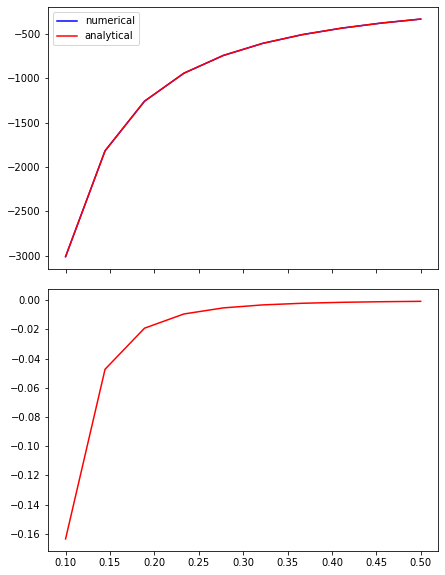

In [37]:
fig, ax = plt.subplots(2, 1, figsize=(7, 10), sharex=True)
ax[0].plot(r, dev_num, color="blue", label="numerical")
ax[0].plot(r, dev_ana, color="red", label="analytical")
ax[0].legend()

ax[1].plot(r, dev_num-dev_ana, color="red")

fig.subplots_adjust(hspace=0.08)

**Check derivative wrt M**

In [ ]:
from utils import temperature_withDM, gNFW_rho
from astropy.constants import R_jup, G, sigma_sb

_sigma_sb = sigma_sb.value 
conversion_into_K_vs_kg = 1.60217e-7                                            
conversion_into_w       = 0.16021766                                            
conv_Msun_to_kg         = 1.98841e+30 # [kg/Msun]  

In [38]:
# Numerical derivative

from scipy.misc import derivative

def derivando(M):    
    f=1.
    params=[1.5, 20., 0.42]
    v=100.
    # return
    return (temperature_withDM(0.1, 0., f=f, M=M*conv_Msun_to_kg, p=params, v=v))


In [42]:
M = np.linspace(0.014, 0.052)

dev_num  = derivative(derivando, M, dx=1e-4)#dx=1e-3)
dev_ana  = derivativeTDM_wrt_M(0.1, 1., [1.5, 20., 0.42], M, v=100.)

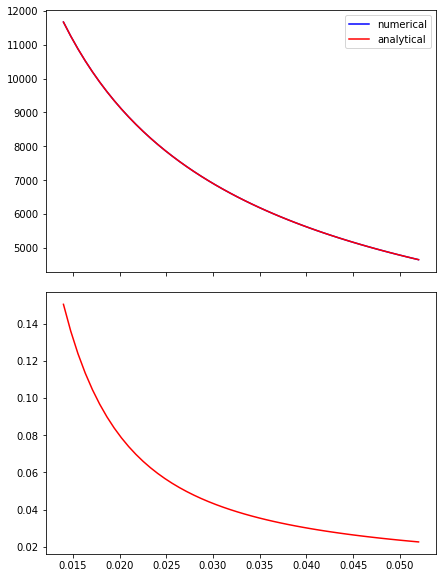

In [43]:
fig, ax = plt.subplots(2, 1, figsize=(7, 10), sharex=True)
ax[0].plot(M, dev_num, color="blue", label="numerical")
ax[0].plot(M, dev_ana, color="red", label="analytical")
ax[0].legend()

ax[1].plot(M, dev_num-dev_ana, color="red")

fig.subplots_adjust(hspace=0.08)

### Create maps for derivative of intrinsic temperature wrt mass

In [5]:
from derivatives import derivativeTint_wrt_M

conv_Msun_to_Mjup = 1047.5655146604772 # [Mjup/Msun]

# Load theoretical cooling model
path          = "./data/"                                                                
data          = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)            
points        = np.transpose(data[0:2, :])  
points_inMjup = np.array([points[:, 0], points[:, 1]*conv_Msun_to_Mjup]).T
values        = data[2]  

In [13]:
stepsA = 50
stepsM = 50
A      = np.linspace(1.002, 9.998, stepsA)
M      = np.linspace(0.015, 0.051, stepsM) 

derv   = np.zeros((stepsA, stepsM))

for i in range(stepsA):
    for j in range(stepsM):
        derv[i][j] = derivativeTint_wrt_M_inMjup(M[j], A[i], points_inMjup, values)

In [14]:
np.savetxt("grid_derivative_Tint_MinMjup_50.dat", derv, fmt='%s')

#!head grid_derivative_Tint_M.dat

In [16]:
from scipy.interpolate import interp2d


_derv = np.loadtxt("grid_derivative_Tint_MinMjup_50.dat", dtype=np.object)

print(derv.shape, _derv.shape)

derv_interp = interp2d(A, M, _derv.T)

(50, 50) (50, 50)


Text(0.5, 0, 'Age [Gyr]')

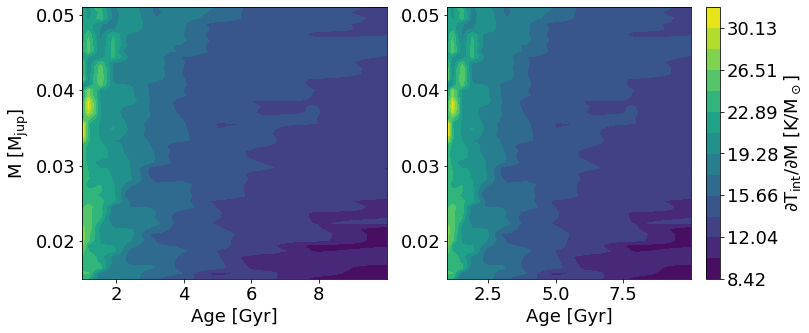

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

levels = np.linspace(np.min(derv), np.max(derv), 14)

cs   = ax[0].contourf(A, M, derv.T, levels=levels)
cbar = fig.colorbar(cs)
cbar.set_label(r"$\partial$T$_{\rm int}$/$\partial$M [K/M$_\odot$]")
ax[0].set_ylabel(r"M [M$_{\rm jup}$]")
ax[0].set_xlabel("Age [Gyr]")


cs = ax[1].contourf(A, M, derv_interp(A, M), levels=levels)
cbar.set_label(r"$\partial$T$_{\rm int}$/$\partial$M [K/M$_\odot$]")
ax[1].set_xlabel("Age [Gyr]")

Text(0.5, 0, 'Age [Gyr]')

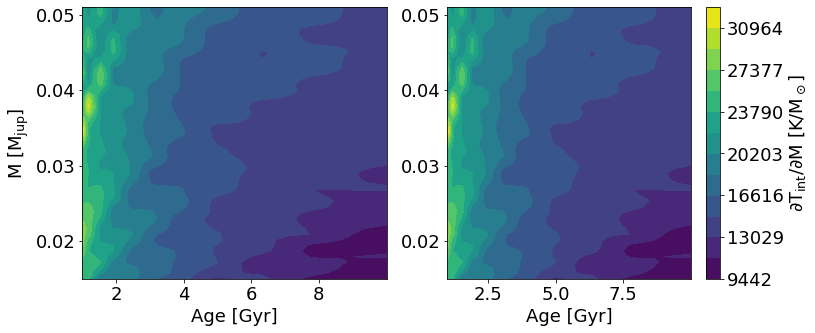

In [152]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

levels = np.linspace(np.min(derv), np.max(derv), 14)

cs   = ax[0].contourf(A, M, derv.T, levels=levels)
cbar = fig.colorbar(cs)
cbar.set_label(r"$\partial$T$_{\rm int}$/$\partial$M [K/M$_\odot$]")
ax[0].set_ylabel(r"M [M$_{\rm jup}$]")
ax[0].set_xlabel("Age [Gyr]")


cs = ax[1].contourf(A, M, derv_interp(A, M), levels=levels)
cbar.set_label(r"$\partial$T$_{\rm int}$/$\partial$M [K/M$_\odot$]")
ax[1].set_xlabel("Age [Gyr]")

In [69]:
import imp
import mock_generation
imp.reload(mock_generation)
from mock_generation import mock_population_all

## Test count map interpolation!

nBDs=100; sigma=0.1; f_true=1.; gamma_true=1.; rs_true=15.; rho0=0.42

robs, sigmarobs, Tobs, sigmaTobs, Mobs, sigmaMobs, Aobs, sigmaAobs = mock_population_all(nBDs, sigma,                
                                                sigma, sigma,                      
                                                sigma, f_true, gamma_true,         
                                                rs_true, rho0_true=rho0,           
                                                Tmin=0., v=100.)
# One-by-one derivative
derv_num = []
for i in range(len(robs)):
    derv_num.append(derivativeTint_wrt_M(Mobs[i], Aobs[i], points, values))

In [71]:
# Interpolating!  
stepsA = 100
stepsM = 100
A      = np.linspace(1.002, 9.998, stepsA)
M      = np.linspace(0.015, 0.051, stepsM)

_derv       = np.loadtxt("grid_derivative_Tint_M.dat", dtype=np.object)
derv_interp = interp2d(A, M, _derv.T)
derv_up     = derv_interp(Aobs, Mobs)

print(np.shape(derv_up))

derv_up_trace = np.diagonal(derv_up)

print(derv_up_trace.shape)

(100, 100)
(100,)


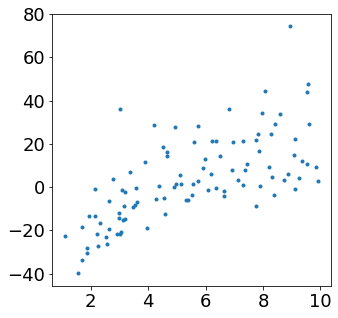

In [72]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax.plot(Aobs, (derv_up_trace-derv_num)/derv_num*100, ".")

### Checking weigth of each of the derivatives

In [89]:
from astropy.constants import R_jup, G, sigma_sb
from utils import T_DM

conv_Msun_to_kg         = 1.98841e+30 # [kg/Msun]
conversion_into_K_vs_kg = 1.60217e-7                                            
conversion_into_w       = 0.16021766 
_G                      = G.value
_sigma_sb               = sigma_sb.value

In [90]:
nBDs=100; sigma=0.1; f_true=1.; gamma_true=1.; rs_true=15.; rho0=0.42

robs, sigmarobs, Tobs, sigmaTobs, Mobs, sigmaMobs, Aobs, sigmaAobs = mock_population_all(nBDs, sigma,                
                                                sigma, sigma,                      
                                                sigma, f_true, gamma_true,         
                                                rs_true, rho0_true=rho0,           
                                                Tmin=0., v=100.)

In [98]:
# Load theoretical cooling model
path = "./data/"                                                                
data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)            
points = np.transpose(data[0:2, :])                                             
values = data[2]  

# calculate predictic intrinsic heat flow for mock BDs                         
xi   = np.transpose(np.asarray([Aobs, Mobs]))                                     
Tint = griddata(points, values, xi)

M_in_kg = Mobs*conv_Msun_to_kg
f = 1.5; params=[1.5, 5., 0.42]; v=100; epsilon=1.

_TDM = T_DM(robs, M=M_in_kg, Rsun=8.178, f=f, params=params, v=v, epsilon=epsilon)
Ttot = np.power(_TDM**4 + Tint**4, 0.25)

In [99]:
from derivatives import derivativeTint_wrt_A, derivativeTDM_wrt_r, derivativeTint_wrt_M, derivativeT_wrt_M


derv_wrt_A = np.ones(len(robs))
derv_wrt_M = np.ones(len(robs))
derv_wrt_R = np.ones(len(robs))

for i in range(len(robs)):
    derv_wrt_A[i] = (Tint[i]/Ttot[i])**3*derivativeTint_wrt_A(Mobs[i], Aobs[i], points, values)
    derv_wrt_M[i] = derivativeT_wrt_M(robs[i], Mobs[i], Aobs[i], Tint[i], _TDM[i], points, values, f, params, v=v, Rsun=8.178, epsilon=epsilon)
    derv_wrt_R[i] = (_TDM[i]/Ttot[i])**3*derivativeTDM_wrt_r(robs[i], f, params, Mobs[i], v=v, Rsun=8.178, epsilon=epsilon)

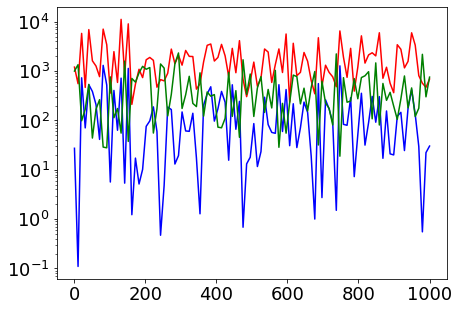

In [100]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

ax.plot(np.linspace(1, 1000, len(robs)), (derv_wrt_A*sigmaAobs)**2, color="blue")
ax.plot(np.linspace(1, 1000, len(robs)), (derv_wrt_M*sigmaMobs)**2, color="red")
ax.plot(np.linspace(1, 1000, len(robs)), (derv_wrt_R*sigmarobs)**2, color="green")

ax.set_yscale("log")

### Checking units for derivative wrt mass -- would it be better to use K/Msun instead of K/Mjup

In [10]:
from astropy.constants import M_sun, M_jup, R_jup
from derivatives import derivativeTint_wrt_M, derivativeT_wrt_M
from scipy.misc import derivative 
from scipy.interpolate import interp1d
from utils import gNFW_rho


conv_Msun_to_Mjup = 1047.5655146604772 # [Mjup/Msun]

def derivativeTint_wrt_M_inMjup(M, A, points, values, size=7000, h=0.001):                
    """                                                                            
    Return (numerical) derivative of intrinsic temperature wrt mass [K/Mjup]    
                                                                                   
    Input                                                                          
    -----                                                                          
        M : mass [Msun]                                                            
        A : age [Gyr]                                                              
    """   
    M      = M*conv_Msun_to_Mjup
    ages   = np.ones(size)*A                                                       
    mass   = np.linspace(0.013*conv_Msun_to_Mjup, 0.053*conv_Msun_to_Mjup, size)                                       
    xi     = np.transpose(np.asarray([ages, mass]))                                
    Teff   = griddata(points, values, xi)
    # return                                                                       
    return derivative(interp1d(mass, Teff), M, dx=h)  


def derivativeTDM_wrt_M_inMjup(r, f, params, M, v=None, R=R_jup.value, Rsun=8.178,     
                        epsilon=1):                                             
    """                                                                         
    Return (analytical) derivative of DM temperature wrt mass @                 
    (f, gamma, rs, rho0, r, M, R) [K/Msun]                                      
                                                                                
    Input                                                                       
    -----                                                                       
        r      : Galactocentric distance [kpc]                                  
        params : DM parameters [f, gamma, rs]                                   
        M      : exoplanet mass [Msun]                                          
    """                                                                         
    # escape velocity                                                           
    vesc   = np.sqrt(2*_G*M*conv_Msun_to_kg/R)*1e-3 # km/s                      
    if v:                                                                       
        _vD = v                                                                 
        #print(_vD, "here i am")                                                
    else:                                                                       
        _vD    = np.sqrt(3/2.)*vc(Rsun, r, params) # km/s                       
                                                                                
    _vDM   =  np.sqrt(8./(3*np.pi))*_vD # km/s                                  
    _rhoDM = gNFW_rho(Rsun, r, params) # GeV/cm3                                
                                                                                
    # DM temperature^-3 [1/K^3]                                                 
    T_DM3 = np.power((f*_rhoDM*_vDM*(1+3./2.*np.power(vesc/_vD, 2))*            
                     conversion_into_w)/(4*_sigma_sb*epsilon), -3./4.)          
    # return                                                                    
    return (T_DM3*3./16.*np.sqrt(8./3./np.pi)*f/_sigma_sb/                      
            epsilon*_rhoDM*_G/_vD/R*                                            
            conversion_into_K_vs_kg*conv_Msun_to_kg / conv_Msun_to_Mjup                            
           )                                                                    
              

def derivativeT_wrt_M_inMjup(r, M, A, Tint, TDM, points, values, f, params,               
                      size=7000, h=0.001, v=None,                                  
                      R=R_jup.value, Rsun=8.178, epsilon=1):                       
    """                                                                         
    Return derivatite of (intrinsic + DM) temperature wrt mass [K/Msun]         
                                                                                
    Input                                                                       
    -----                                                                       
        r : Galactocentric distance [kpc]                                       
        M : mass [Msun]                                                         
        A : age [Gyr]                                                           
    """                                                                            
    Ttot = np.power(TDM**4 + Tint**4, 0.25)                                        
    # return                                                                       
    return ((Tint/Ttot)**3*derivativeTint_wrt_M_inMjup(M, A, points, values, size=size, 
                                                h=h) +                             
            (TDM/Ttot)**3*derivativeTDM_wrt_M_inMjup(r, f, params, M, v=v, R=R, Rsun=Rsun,
                                              epsilon=epsilon)                     
           ) 

In [142]:
nBDs=100; sigma=0.1; f_true=1.; gamma_true=1.; rs_true=15.; rho0=0.42

robs, sigmarobs, Tobs, sigmaTobs, Mobs, sigmaMobs, Aobs, sigmaAobs = mock_population_all(nBDs, sigma,                
                                                sigma, sigma,                      
                                                sigma, f_true, gamma_true,         
                                                rs_true, rho0_true=rho0,           
                                                Tmin=0., v=100.)

# Load theoretical cooling model
path = "./data/"                                                                
data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)            
points = np.transpose(data[0:2, :])                                             
values = data[2]  

In [143]:
points_inMjup = np.array([points[:, 0], points[:, 1]*conv_Msun_to_Mjup]).T
print(points_inMjup.shape, points.shape)

(7100, 2) (7100, 2)


In [144]:
derv_wrt_Minjup = np.ones(len(robs))
derv_wrt_M      = np.ones(len(robs))

for i in range(len(robs)):
    derv_wrt_Minjup[i] = derivativeT_wrt_M_inMjup(robs[i], Mobs[i], Aobs[i], Tint[i], _TDM[i], points_inMjup, values, f, params, v=v, Rsun=8.178, epsilon=epsilon)
    
    derv_wrt_M[i] = derivativeT_wrt_M(robs[i], Mobs[i], Aobs[i], Tint[i], _TDM[i], points, values, f, params, v=v, Rsun=8.178, epsilon=epsilon)


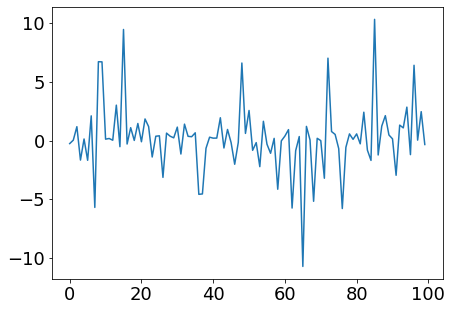

In [149]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

ax.plot(((derv_wrt_Minjup*sigmaMobs*conv_Msun_to_Mjup)**2 - (derv_wrt_M*sigmaMobs)**2)/(derv_wrt_M*sigmaMobs)**2*100)

## Check mock generation again

In [56]:
import mock_generation
import imp
imp.reload(mock_generation)
import utils
imp.reload(utils)
from mock_generation import mock_population_all
from astropy.constants import M_sun

nBDs = 10000
sigma_rel_Tobs = 0.3; sigma_rel_Mobs = 0.3; sigma_rel_Aobs = 0.3; sigma_rel_robs = 0.3
f_true = 1.; gamma_true=1.5; rs_true=20.; rho0_true=0.42

np.random.seed(21)
(robs, sigmarobs, Tobs, sigmaTobs, Mobs, 
 sigmaMobs, Aobs, sigmaAobs) = mock_population_all(nBDs, sigma_rel_Tobs, sigma_rel_Mobs, sigma_rel_robs, 
                                                sigma_rel_Aobs, f_true, gamma_true, 
                                                rs_true, rho0_true=rho0_true, Tmin=0., v=100.)

# Load theoretical cooling model
path   = "./data/"                                                                
data   = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)            
points = np.transpose(data[0:2, :])                                             
values = data[2]  
# calculate predictic intrinsic heat flow for mock BDs                         
xi       = np.transpose(np.asarray([Aobs, Mobs]))                                     
Teff     = griddata(points, values, xi)  

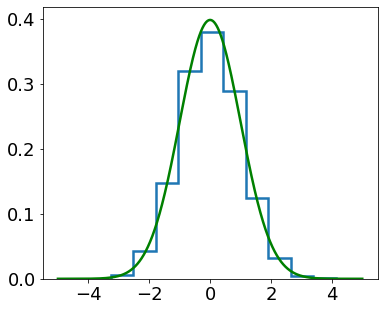

In [55]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

Tmodel = temperature_withDM(robs, Teff, M=Mobs*M_sun.value, 
                            f=f_true, p=[gamma_true, rs_true, rho0_true], v=100.)

#ax.plot(Tmodel-sigmaTobs/0.1)
ax.hist((Tobs-Tmodel)/sigmaTobs, histtype="step", linewidth=2.5, density=True);

from scipy.stats import norm
x = np.arange(-5, 5, 0.001)
y = norm.pdf(x, 0, 1)
ax.plot(x, y, lw=2.5, color="green")

In [57]:
from astropy.constants import R_jup, sigma_sb, G
from utils import T_DM
from derivatives import derivativeTint_wrt_A, derivativeT_wrt_M, derivativeTDM_wrt_r

_sigma_sb = sigma_sb.value                                                      
_G        = G.value                                                             
conversion_into_K_vs_kg = 1.60217e-7                                            
conversion_into_w       = 0.16021766                                            
conv_Msun_to_kg         = 1.98841e+30 # [kg/Msun] 

def sigma_Tmodel2(r, M, A, sigma_r, sigma_M, sigma_A, 
                  Tint, points, values, f, params, v=None, 
                  R=R_jup.value, Rsun=8.178, epsilon=1, 
                  size=7000, h=1e-3):
    """
    Return squared uncertainty in model temperature [UNITS??]
    
    Input:
        r : Galactocentric distance [kpc]
        M : mass [Msun]
        A : age [Gyr]
    
    Assumption: uncertainties in age, mass and galactocentric distance are independent
    """
    M_in_kg = M*conv_Msun_to_kg
    
    _TDM = T_DM(r, R=R, M=M_in_kg, Rsun=Rsun, f=f, params=params, v=v, epsilon=epsilon)
    Ttot = np.power(_TDM**4 + Tint**4, 0.25)

    # return
    return (np.power((Tint/Ttot)**3*derivativeTint_wrt_A(M, A, points, values, size=size, h=h)*sigma_A, 2)+ 
            
            np.power(derivativeT_wrt_M(r, M, A, Tint, _TDM, points, values, f, params, size=size, 
                                       h=h, v=v, R=R, Rsun=Rsun, epsilon=epsilon)*sigma_M, 2) + 
            
            np.power((_TDM/Ttot)**3*derivativeTDM_wrt_r(r, f, params, M, v=v, R=R, 
                                                        Rsun=Rsun, epsilon=epsilon)*sigma_r, 2))


sigma_model2 = np.ones(len(robs))
for i in range(len(robs)):
    sigma_model2[i] = sigma_Tmodel2(robs[i], Mobs[i], Aobs[i], sigmarobs[i], sigmaMobs[i], sigmaAobs[i], 
              Teff[i], points, values, f_true, [gamma_true, rs_true, rho0_true], 
              v=100., R=R_jup.value, Rsun=8.178, 
              epsilon=1., size=7000, h=1e-3)

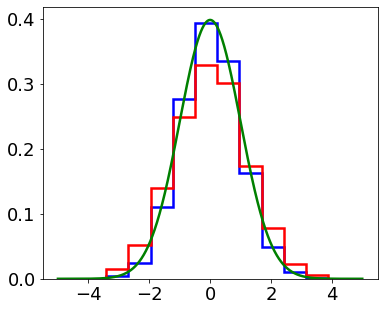

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

Tmodel = temperature_withDM(robs, Teff, M=Mobs*M_sun.value, 
                            f=f_true, p=[gamma_true, rs_true, rho0_true], v=100.)

#ax.plot(Tmodel-sigmaTobs/0.1)
counts_eff, bins_eff, _ = ax.hist((Tobs-Tmodel)/np.sqrt(sigmaTobs**2 + sigma_model2), 
                                  histtype="step", linewidth=2.5, color="b", density=True);
ax.hist((Tobs-Tmodel)/sigmaTobs, bins=bins_eff, histtype="step", linewidth=2.5, color="r", density=True);

from scipy.stats import norm
x = np.arange(-5, 5, 0.001)
y = norm.pdf(x, 0, 1)
ax.plot(x, y, lw=2.5, color="green")

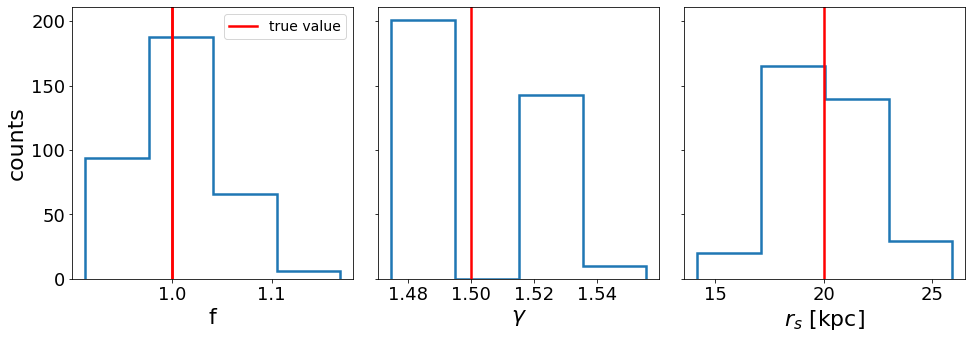

In [11]:
nBDs       = 1000
sigma      = 0.1
f_true     = 1.
gamma_true = 1.5
rs_true    = 20.
path       = "/home/mariacst/exoplanets/exoplanets/python/checks/"

f_ML, gamma_ML, rs_ML = np.genfromtxt(path + "check_likelihood_nBDs%i_sigmaT100sigma%.1f_gamma%.1f_rs%.1f.dat" 
               %(nBDs, sigma, gamma_true, rs_true), unpack=True)
    
fig, ax = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

pos = np.where(f_ML > 0.)
ax[0].hist(f_ML[pos], histtype="step", linewidth=2.5, bins=4); 
ax[1].hist(gamma_ML[pos], histtype="step", linewidth=2.5, bins=4); 
ax[2].hist(rs_ML[pos], histtype="step", linewidth=2.5, bins=4);

ax[0].axvline(f_true, color="red", lw=2.5); ax[1].axvline(gamma_true, color="red", lw=2.5);
ax[2].axvline(rs_true, color="red", lw=2.5);

ax[0].axvline(f_true, color="red", lw=2.5, label="true value")
ax[0].legend(fontsize=14)
ax[0].set_ylabel(r"counts", fontsize=22)
ax[0].set_xlabel("f", fontsize=22)
ax[1].set_xlabel(r"$\gamma$", fontsize=22)
ax[2].set_xlabel(r"$r_s$ [kpc]", fontsize=22)
fig.subplots_adjust(wspace=0.09)

fig.savefig("histML_nBDs%i_sigma%.1f_gamma%.1f_rs%.1f.pdf"%(nBDs, sigma, gamma_true, rs_true), 
            bbox_inches="tight")

## Checking

0.6431736664801423 1.4009772433889691 2.380497353267924


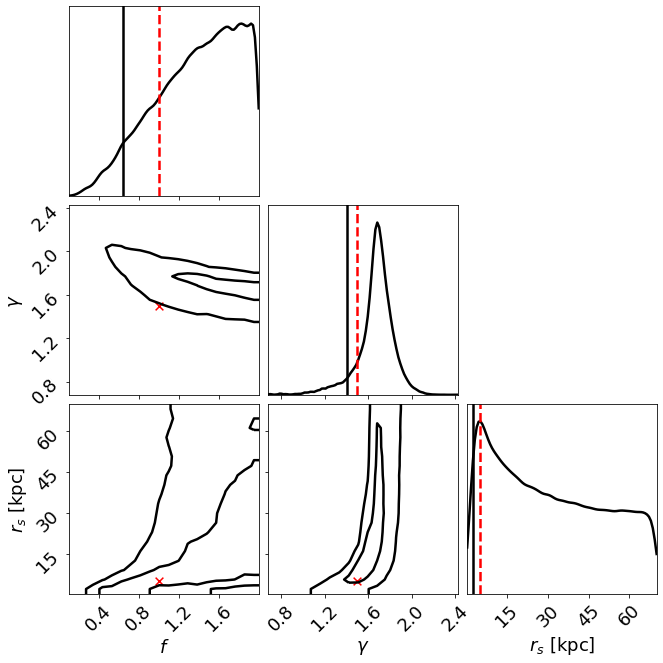

In [11]:
nBDs = 100
gamma_true=1.5

_path   = "/home/mariacst/exoplanets/running/checks/"
_file   = open(_path + 
               "like_N%i_sigma%.1f_f%.1fgamma%.1frs%.1fv0" %(nBDs, 0.1, 1., gamma_true, 5.),
               "rb") 
like    = pickle.load(_file)
_file   = open(_path +
               "poseterior_N%i_sigma%.1f_f%.1fgamma%.1frs%.1fv0" %(nBDs, 0.1, 1., gamma_true, 5.),
               "rb") 
samples = pickle.load(_file)

smooth=0.5
fig, axes = corner(samples, levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
                   plot_density=False, fill_contours=False, smooth=smooth)

# plot KDE smoothed version of distributions
for axidx, samps in zip([0, 4, 8], samples.T):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim()
    xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="k", lw=2.5) 

ML = samples[np.argmax(like)]
axes[0, 0].axvline(ML[0], ls="-", lw=2.5, color="k"); axes[0, 0].axvline(1., color="r", ls="--", lw=2.5)
axes[1, 1].axvline(ML[1], ls="-", lw=2.5, color="k"); axes[1, 1].axvline(gamma_true, color="r", ls="--", lw=2.5)
axes[2, 2].axvline(ML[2], ls="-", lw=2.5, color="k");axes[2, 2].axvline(5., color="r", ls="--", lw=2.5)

axes[1, 0].scatter(1., gamma_true, marker="x", color="red", s=60)
axes[2, 0].scatter(1., 5., marker="x", color="red", s=60)
axes[2, 1].scatter(gamma_true, 5., marker="x", color="red", s=60)

axes[1, 0].set_ylabel(r"$\gamma$")
axes[2, 0].set_xlabel(r"$f$")
axes[2, 0].set_ylabel(r"$r_s$ [kpc]")
axes[2, 1].set_xlabel(r"$\gamma$")
axes[2, 2].set_xlabel(r"$r_s$ [kpc]")

print(ML[0], ML[1], ML[2])

0.3870144226159251 1.2421571055313703 2.4001754608052916


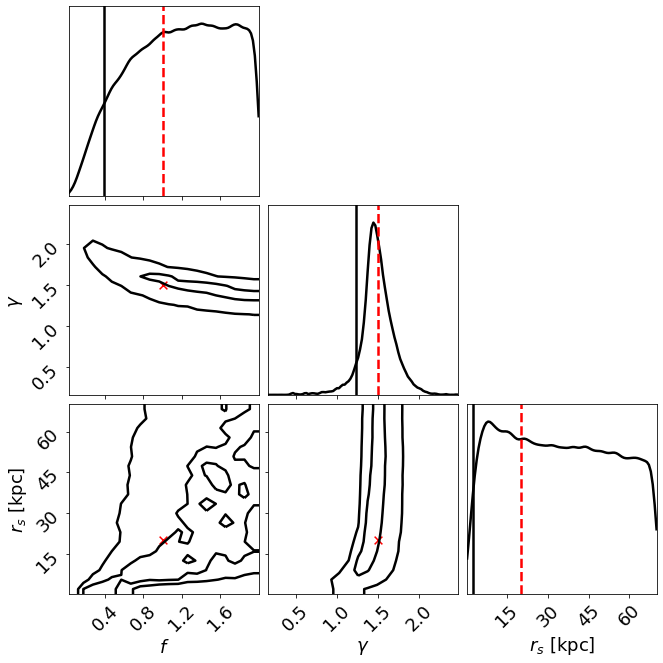

In [12]:
nBDs = 100
gamma_true=1.5

_path   = "/home/mariacst/exoplanets/running/checks/"
_file   = open(_path + 
               "like_N%i_sigma%.1f_f%.1fgamma%.1frs%.1fv0" %(nBDs, 0.1, 1., gamma_true, 20.),
               "rb") 
like    = pickle.load(_file)
_file   = open(_path +
               "poseterior_N%i_sigma%.1f_f%.1fgamma%.1frs%.1fv0" %(nBDs, 0.1, 1., gamma_true, 20.),
               "rb") 
samples = pickle.load(_file)

smooth=0.5
fig, axes = corner(samples, levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
                   plot_density=False, fill_contours=False, smooth=smooth)

# plot KDE smoothed version of distributions
for axidx, samps in zip([0, 4, 8], samples.T):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim()
    xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="k", lw=2.5) 

ML = samples[np.argmax(like)]
axes[0, 0].axvline(ML[0], ls="-", lw=2.5, color="k"); axes[0, 0].axvline(1., color="r", ls="--", lw=2.5)
axes[1, 1].axvline(ML[1], ls="-", lw=2.5, color="k"); axes[1, 1].axvline(gamma_true, color="r", ls="--", lw=2.5)
axes[2, 2].axvline(ML[2], ls="-", lw=2.5, color="k");axes[2, 2].axvline(20., color="r", ls="--", lw=2.5)

axes[1, 0].scatter(1., gamma_true, marker="x", color="red", s=60)
axes[2, 0].scatter(1., 20., marker="x", color="red", s=60)
axes[2, 1].scatter(gamma_true, 20., marker="x", color="red", s=60)

axes[1, 0].set_ylabel(r"$\gamma$")
axes[2, 0].set_xlabel(r"$f$")
axes[2, 0].set_ylabel(r"$r_s$ [kpc]")
axes[2, 1].set_xlabel(r"$\gamma$")
axes[2, 2].set_xlabel(r"$r_s$ [kpc]")

print(ML[0], ML[1], ML[2])

In [2]:
sys.path.append("/home/mariacst/exoplanets/running/checks")
from emcee_functions import sigma_Tmodel2, residual
from utils import temperature_withDM
from mock_generation import mock_population_check
from derivatives import derivativeTint_wrt_A, derivativeTint_wrt_M
from astropy.constants import R_jup
from matplotlib import rc
rc('font', family='times new roman', size=12.)

conv_Msun_to_kg = 1.98841e+30 # [kg/Msun]

In [3]:
def simu_stat(seed, nBDs, sigma, f_true, gamma_true, rs_true):
    np.random.seed(seed)
    rfid, _, Tfid, _, _, _, _, _ = mock_population_check(nBDs, 0., 0., 0., 0., f_true, gamma_true, rs_true, v=100.)  
    np.random.seed(seed)
    robs, sigmarobs, Tobs, sigmaTobs, Mobs, sigmaMobs, Aobs, sigmaAobs = mock_population_check(nBDs, 100., sigma,        
                                            sigma, sigma, f_true, gamma_true, rs_true, v=100.) 
    
    # Calculate derivatives Tint wrt Age and Mass                               
    dervTint_A = np.ones(nBDs)                                                     
    dervTint_M = np.ones(nBDs)                                                     
    for i in range(nBDs):                                                          
        dervTint_A[i] = derivativeTint_wrt_A(Mobs[i], Aobs[i], points, values,  
                                             size=size, h=h)                       
        dervTint_M[i] = derivativeTint_wrt_M(Mobs[i], Aobs[i], points, values,  
                                             size=size, h=h)      
        
    # calculate predictic intrinsic heat flow for mock BDs                      
    xi   = np.transpose(np.asarray([Aobs, Mobs]))                                 
    Teff = griddata(points, values, xi)
    
    Npoints = 100                                                                  
                                                                                       
    f          = np.linspace(0.01, 1.5, Npoints)                                   
    gamma      = np.linspace(0., 2., Npoints)                                      
    rs         = np.linspace(0.1, 45., Npoints)                                    
    like_f     = np.zeros(Npoints)                                                 
    like_gamma = np.zeros(Npoints)                                                 
    like_rs    = np.zeros(Npoints)                                                 
                                                                                   
    for i in range(Npoints): # Puedo eliminar este for loop??                                                      
        like_f[i]     = residual([f[i], gamma_true, rs_true], robs, sigmarobs, Mobs,
                         sigmaMobs, Aobs, sigmaAobs,                            
                         Tobs, sigmaTobs, Teff, points, values, dervTint_M,     
                         dervTint_A, 100., R_jup.value, 8.178, 0.42, 1.)           
        like_gamma[i] = residual([f_true, gamma[i], rs_true], robs, sigmarobs, Mobs,
                         sigmaMobs, Aobs, sigmaAobs,                            
                         Tobs, sigmaTobs, Teff, points, values, dervTint_M,     
                         dervTint_A, 100., R_jup.value, 8.178, 0.42, 1.)        
        like_rs[i]   = residual([f_true, gamma_true, rs[i]], robs, sigmarobs, Mobs,
                         sigmaMobs, Aobs, sigmaAobs,                            
                         Tobs, sigmaTobs, Teff, points, values, dervTint_M,     
                         dervTint_A, 100., R_jup.value, 8.178, 0.42, 1.)        
                                                                                
    ML_f = f[np.argmax(like_f)]                                             
    ML_g = gamma[np.argmax(like_gamma)]                                     
    ML_r = rs[np.argmax(like_rs)]
    
    Tbf_f = temperature_withDM(robs, Teff, M=Mobs*conv_Msun_to_kg, f=ML_f, p=[gamma_true, rs_true, rho0], v=100.)
    Tbf_g = temperature_withDM(robs, Teff, M=Mobs*conv_Msun_to_kg, f=f_true, p=[ML_g, rs_true, rho0], v=100.)
    Tbf_r = temperature_withDM(robs, Teff, M=Mobs*conv_Msun_to_kg, f=f_true, p=[gamma_true, ML_r, rho0], v=100.)
    
    sigma_T_f = sigma_Tmodel2(robs, Mobs, Aobs, sigmarobs, sigmaMobs, sigmaAobs, Teff, points, values, 
                              dervTint_M, dervTint_A, ML_f, [gamma_true, rs_true, rho0], v=100.) 
    sigma_T_g = sigma_Tmodel2(robs, Mobs, Aobs, sigmarobs, sigmaMobs, sigmaAobs, Teff, points, values, 
                              dervTint_M, dervTint_A, f_true, [ML_g, rs_true, rho0], v=100.)
    sigma_T_r = sigma_Tmodel2(robs, Mobs, Aobs, sigmarobs, sigmaMobs, sigmaAobs, Teff, points, values, 
                              dervTint_M, dervTint_A, f_true, [gamma_true, ML_r, rho0], v=100.)
    
    return rfid, Tfid, robs, Tobs, Tbf_f, Tbf_g, Tbf_r, sigma_T_f, sigma_T_g, sigma_T_r

KeyboardInterrupt: 

findfont: Font family ['times new roman'] not found. Falling back to DejaVu Sans.


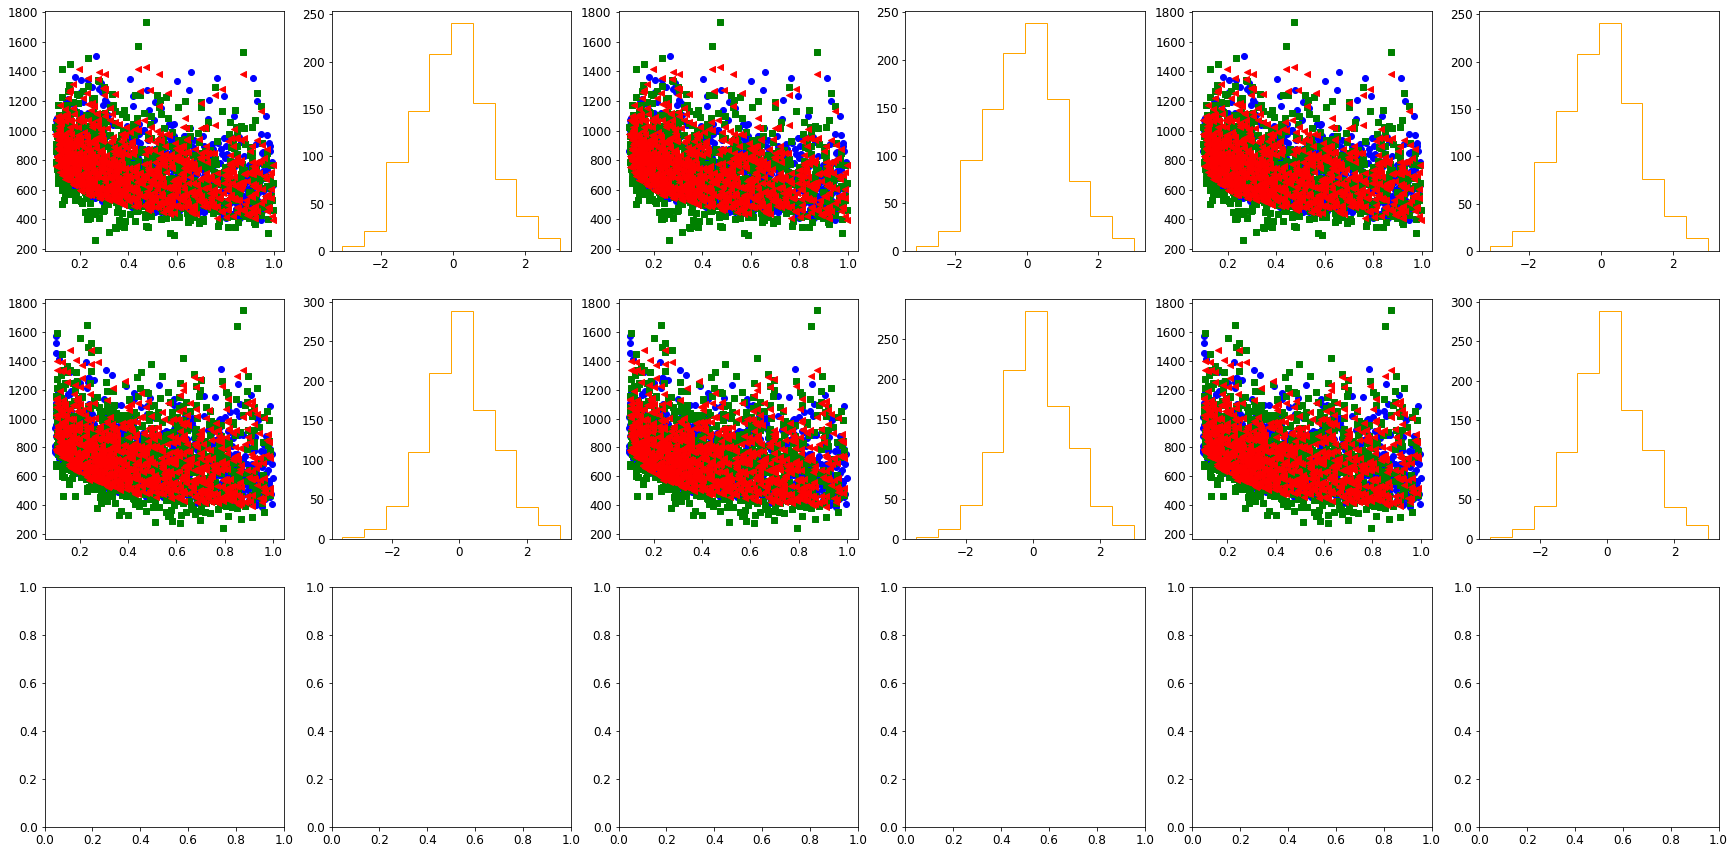

In [4]:
nBDs       = 1000
sigma      = 0.1
f_true     = 1.
gamma_true = 1.5
rs_true    = 20.
rho0       = 0.42

# Load theoretical cooling model                                                   
path   = "../data/"                                                                
data   = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)            
points = np.transpose(data[0:2, :])                                             
values = data[2]                                                                   
size   = 7000                                                                      
h      = 0.001

fig, ax = plt.subplots(3, 6, figsize=(30, 15))

rfid, Tfid, robs, Tobs, Tbf_f, Tbf_g, Tbf_r, s_f, s_g, s_r = simu_stat(21, nBDs, sigma, f_true, gamma_true, rs_true)

ax[0, 0].scatter(rfid, Tfid, color="blue", marker="o", label="fiducial")
ax[0, 2].scatter(rfid, Tfid, color="blue", marker="o")
ax[0, 4].scatter(rfid, Tfid, color="blue", marker="o",)
ax[0, 0].scatter(robs, Tobs, color="g", marker="s", label="obs")
ax[0, 2].scatter(robs, Tobs, color="g", marker="s",)
ax[0, 4].scatter(robs, Tobs, color="g", marker="s")
ax[0, 0].scatter(robs, Tbf_f, color="r", marker="<", label="BF")
ax[0, 2].scatter(robs, Tbf_g, color="r", marker="<",)
ax[0, 4].scatter(robs, Tbf_r, color="r", marker="<")

ax[0, 1].hist((Tobs-Tbf_f)/np.sqrt(s_f + 100**2), histtype="step", color="orange");
ax[0, 3].hist((Tobs-Tbf_g)/np.sqrt(s_g + 100**2), histtype="step", color="orange");
ax[0, 5].hist((Tobs-Tbf_r)/np.sqrt(s_r + 100**2), histtype="step", color="orange");

rfid, Tfid, robs, Tobs, Tbf_f, Tbf_g, Tbf_r, s_f, s_g, s_r = simu_stat(35, nBDs, sigma, f_true, gamma_true, rs_true)

ax[1, 0].scatter(rfid, Tfid, color="blue", marker="o", label="fiducial")
ax[1, 2].scatter(rfid, Tfid, color="blue", marker="o")
ax[1, 4].scatter(rfid, Tfid, color="blue", marker="o",)
ax[1, 0].scatter(robs, Tobs, color="g", marker="s", label="obs")
ax[1, 2].scatter(robs, Tobs, color="g", marker="s",)
ax[1, 4].scatter(robs, Tobs, color="g", marker="s")
ax[1, 0].scatter(robs, Tbf_f, color="r", marker="<", label="BF")
ax[1, 2].scatter(robs, Tbf_g, color="r", marker="<",)
ax[1, 4].scatter(robs, Tbf_r, color="r", marker="<")

ax[1, 1].hist((Tobs-Tbf_f)/np.sqrt(s_f + 100**2), histtype="step", color="orange");
ax[1, 3].hist((Tobs-Tbf_g)/np.sqrt(s_g + 100**2), histtype="step", color="orange");
ax[1, 5].hist((Tobs-Tbf_r)/np.sqrt(s_r + 100**2), histtype="step", color="orange");

rfid, Tfid, robs, Tobs, Tbf_f, Tbf_g, Tbf_r, s_f, s_g, s_r = simu_stat(6, nBDs, sigma, f_true, gamma_true, rs_true)

ax[2, 0].scatter(rfid, Tfid, color="blue", marker="o", label="fiducial")
ax[2, 2].scatter(rfid, Tfid, color="blue", marker="o")
ax[2, 4].scatter(rfid, Tfid, color="blue", marker="o",)
ax[2, 0].scatter(robs, Tobs, color="g", marker="s", label="obs")
ax[2, 2].scatter(robs, Tobs, color="g", marker="s",)
ax[2, 4].scatter(robs, Tobs, color="g", marker="s")
ax[2, 0].scatter(robs, Tbf_f, color="r", marker="<", label="BF")
ax[2, 2].scatter(robs, Tbf_g, color="r", marker="<",)
ax[2, 4].scatter(robs, Tbf_r, color="r", marker="<")

ax[2, 1].hist((Tobs-Tbf_f)/np.sqrt(s_f + 100**2), histtype="step", color="orange");
ax[2, 3].hist((Tobs-Tbf_g)/np.sqrt(s_g + 100**2), histtype="step", color="orange");
ax[2, 5].hist((Tobs-Tbf_r)/np.sqrt(s_r + 100**2), histtype="step", color="orange");


ax[2, 1].set_xlabel("norm. residuals"); ax[2, 3].set_xlabel("norm. residuals"); ax[2, 5].set_xlabel("norm. residuals");
ax[2, 0].set_xlabel("r [kpc]"); ax[2, 2].set_xlabel("r [kpc]"); ax[2, 4].set_xlabel("r [kpc]")
ax[2, 0].set_ylabel("T [K]"); ax[1, 0].set_ylabel("T [K]"); ax[0, 0].set_ylabel("T [K]")

ax[0, 0].legend()

fig.savefig("check_L_nBDs%i_sigma%.1f_gamma%.1f_rs%.1f.pdf"%(nBDs, sigma, gamma_true, rs_true), bbox_inches="tight")

## Effect of nwalkers and steps

In [18]:
nBDs = 100; sigma = 0.1; fs_true = 1.; gamma_true = 1.5; rs_true = 20.

path = "/home/mariacst/exoplanets/running/checks/"

samples0 = pickle.load(open(path + "posterior_N%i_sigma%.1f_f%.1fgamma%.1frs%.1f_nwalkers50_steps4000" 
                       %(nBDs, sigma, f_true, gamma_true, rs_true), "rb"))
like0    = pickle.load(open(path + "posterior_N%i_sigma%.1f_f%.1fgamma%.1frs%.1f_nwalkers50_steps4000" 
                       %(nBDs, sigma, f_true, gamma_true, rs_true), "rb"))
samples  = pickle.load(open(path + "posterior_N%i_sigma%.1f_f%.1fgamma%.1frs%.1f_nwalkers100_steps5000" 
                       %(nBDs, sigma, f_true, gamma_true, rs_true), "rb"))
like     = pickle.load(open(path + "posterior_N%i_sigma%.1f_f%.1fgamma%.1frs%.1f_nwalkers100_steps5000" 
                       %(nBDs, sigma, f_true, gamma_true, rs_true), "rb"))

In [27]:
from scipy.optimize import minimize 
from scipy.stats import binned_statistic

def LI(L, samples, bin_n=10, verbose=False):                                    
    """                                                                         
    For each parameter, construct profile likelihood and return the profile likelihood interval
    (i.e. region where the log Likelihood is within 1 of its maximum value)     
                                                                                
    """                                                                         
    # Create bins in Likelihood vs parameter space, find the max Likelihood     
    # value in each bin and the corresponding parameter values                  
    x = binned_statistic(samples, -L, 'min', bins=bin_n)[1]                     
    y = binned_statistic(samples, -L, 'min', bins=bin_n+1)[0]                   
                                                                                
    # Create Interpolation fanction Likelihood - parameter                      
    #pdb.set_trace()                                                            
    z =  UnivariateSpline(x, y, s=0)                                            
                                                                                
    # Find in which points crosses 1sigma horizontal line (where 1 sigma        
    # corresponds to 1/2 -for 1 dof-)                                           
    x_tmin     = np.min(samples)                                                
    epsilon    = 1                                                              
    niteration = 0                                                              
    logLmin    = np.min(y) + 0.5                                                
    while epsilon > 10**-6 and niteration < 20:                                 
        niteration +=1                                                          
        minimum = minimize(lambda x: (z(x)-logLmin)**2, x_tmin,                 
                           bounds=((np.min(samples), samples[np.argmax(L)]),))  
        epsilon = minimum.fun                                                   
        x_tmin  = x_tmin*1.1                                                    
        _min    = minimum.x                                                     
                                                                                
    if epsilon < 10**-6:                                                        
        LImin = _min[0]                                                         
    else:                                                                       
        LImin = np.min(samples)                                                 
                                                                                
    x_tmax     = samples[np.argmax(L)]                                          
    epsilon    = 1                                                              
    niteration = 0                                                              
    while epsilon > 10**-6 and niteration < 25:                                 
        niteration +=1                                                          
        maximum = minimize(lambda x: (z(x)-logLmin)**2, x_tmax,                 
                           bounds=((samples[np.argmax(L)], np.max(samples)),))  
        epsilon  = maximum.fun                                                  
        x_tmax  = x_tmax*1.1                                                    
        _max    = maximum.x                                                     
                                                                                
    if epsilon < 10**-6:                                                        
        LImax = _max[0]                                                         
    else:                                                                       
        LImax = np.max(samples)                                                 
                                                                                
    if verbose==True:                                                           
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))                            
        ax.plot(x, y, color="k", lw=2.5)                                        
        ax.axvline(LImin, color="g"); ax.axvline(LImax, color="g")              
                                                                                
    #Return                                                                     
    return  LImin, LImax

def statistics(samples, like, D=3):
    mean       = np.zeros(D)                                               
    median     = np.zeros(D)                                               
    _16th      = np.zeros(D)                                               
    _84th      = np.zeros(D)                                               
    MAP        = np.zeros(D)                                               
    ML         = np.zeros(D)                                               
    LI_min     = np.zeros(D)                                               
    LI_max     = np.zeros(D)
    
    for j in range(D):                                                         
        mean[j]   = np.mean(samples[:, j])                                  
        median[j] = np.percentile(samples[:, j], [50], axis=0)              
        _16th[j]  = np.percentile(samples[:, j], [16], axis=0)              
        _84th[j]  = np.percentile(samples[:, j], [84], axis=0)              
        #TODO need to change # bins to see if results differ                   
        _n, _bins    = np.histogram(samples[:, j], bins=50)                    
        MAP[j]    = _bins[np.argmax(_n)]                                    
        #ML[j]     = samples[:, j][np.argmax(like)]                          
        #_min, _max = LI(like, samples[:, j])                                 
        #LI_min[j] = _min                                                    
        #LI_max[j] = _max 
        
    return mean, median, _16th, _84th, MAP

In [28]:
statistics(samples, like)

(array([ 1.182044  ,  1.4963203 , 34.55364364]),
 array([ 1.20752157,  1.48788518, 33.97679776]),
 array([ 0.6204429 ,  1.34625744, 11.61371274]),
 array([ 1.74345361,  1.67385332, 57.8993201 ]),
 array([1.36889832, 1.41236339, 7.27762379]))

In [29]:
statistics(samples0, like0)

(array([ 1.18367817,  1.4908435 , 33.86491198]),
 array([ 1.21217382,  1.48300917, 33.00171679]),
 array([ 0.6212945 ,  1.33343115, 10.64047189]),
 array([ 1.74315521,  1.67097916, 57.5523195 ]),
 array([1.250329  , 1.44039179, 5.98442578]))